In [1]:
import pandas as pd
import numpy as np
import ast
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, hamming_loss, f1_score, multilabel_confusion_matrix,ConfusionMatrixDisplay
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from skmultilearn.problem_transform import BinaryRelevance, ClassifierChain, LabelPowerset
import fasttext
from transformers import BertTokenizer
import gensim
import gensim.downloader

dataset = pd.read_excel("Synthetic User Stories.xlsx")

labels = pd.read_excel("Keyword labelled.xlsx", header=None)
labels[2] = labels[2].apply(lambda x: x.lower())
labels

c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,classification,NaN,abstractive summarization,Data summarization,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,regression,NaN,action model learning,Other,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ranking,NaN,activation function,Representation learning,Classification,Regression,Anomaly detection,Clustering,Spatio-temporal process learning,Graph diffusion,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,matching,NaN,active learning setting,Classification,Regression,Anomaly detection,Entity resolution,Sentiment analysis,Bias detection in word embeddings,Bias detection in language models,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,risk assessment,NaN,adaboost,Classification,Regression,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,NaN,NaN,word segmentation,Machine translation,Speech recognition,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
363,NaN,NaN,word similarity,Classification,Ranking,Matching,Clustering,Anomaly detection,Sentiment analysis,Entity resolution,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
364,NaN,NaN,word-sense disambiguation,Classification,Ranking,Matching,Clustering,Anomaly detection,Sentiment analysis,Entity resolution,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
365,NaN,NaN,word2vec,Classification,Ranking,Matching,Clustering,Anomaly detection,Sentiment analysis,Entity resolution,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
categories_column = []
for row in labels.iterrows():
    current_labels = []
    for label in row[1][3:]:
        if isinstance(label, str):
            current_labels.append(label.lower())
    categories_column.append(current_labels)
labels["Categories array"] = categories_column
labels[[2, "Categories array"]]

,2,Categories array
0,abstractive summarization,[data summarization]
1,action model learning,[other]
2,activation function,"[representation learning, classification, regr..."
3,active learning setting,"[classification, regression, anomaly detection..."
4,adaboost,"[classification, regression]"
...,...,...
362,word segmentation,"[machine translation, speech recognition]"
363,word similarity,"[classification, ranking, matching, clustering..."
364,word-sense disambiguation,"[classification, ranking, matching, clustering..."
365,word2vec,"[classification, ranking, matching, clustering..."


In [3]:
target = []
counter = 0
for row in dataset.iterrows():
    target.append(labels[labels[2]==row[1]["Machine Learning Task"].lower()]["Categories array"].values[0])
    counter += 1
dataset["Target"] = target
dataset[["User Story","Target"]]

,User Story,Target
0,A group of researchers is using abstractive su...,[data summarization]
1,"As a plant scientist, I want to use abstractiv...",[data summarization]
2,"As a molecular biologist, I want to use action...",[other]
3,"As a plant scientist, I want to use action mod...",[other]
4,"As a bioinformatics researcher, I want to use ...","[representation learning, classification, regr..."
...,...,...
12396,"As a computer vision researcher, I want to use...","[classification, ranking, matching, clustering..."
12397,"As a network engineer, I want to use word2vec ...","[classification, ranking, matching, clustering..."
12398,"As a computer vision researcher, I want to use...","[classification, ranking, matching, clustering..."
12399,"As a network engineer, I want to use WordNet t...","[representation learning, clustering, matching..."


In [4]:
#Cast categories into lists
dataset['Target'] = dataset['Target'].apply(lambda x: ast.literal_eval(str(x)))
dataset['Target']

0                                     [data summarization]
1                                     [data summarization]
2                                                  [other]
3                                                  [other]
4        [representation learning, classification, regr...
                               ...                        
12396    [classification, ranking, matching, clustering...
12397    [classification, ranking, matching, clustering...
12398    [classification, ranking, matching, clustering...
12399    [representation learning, clustering, matching...
12400    [representation learning, clustering, matching...
Name: Target, Length: 12401, dtype: object

In [5]:
multilabel = MultiLabelBinarizer()
y = multilabel.fit_transform(dataset['Target'])
pd.DataFrame(y, columns=multilabel.classes_)

,advertising,anomaly detection,bias detection in language models,bias detection in word embeddings,classification,clustering,data summarization,districting,entity resolution,graph augmentation,...,ranking,regression,representation learning,resource allocation,risk assessment,sentiment analysis,spatio-temporal process learning,speech recognition,subset selection,task assignment
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,1,1,0,0,0,0,...,0,1,1,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12396,0,1,0,0,1,1,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
12397,0,1,0,0,1,1,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
12398,0,1,0,0,1,1,0,0,1,0,...,1,0,0,0,0,1,0,0,0,0
12399,0,1,1,1,0,1,0,0,1,0,...,0,0,1,0,0,1,0,0,1,0


In [6]:
from IPython.display import display, HTML
display(HTML(dataset.Target.apply(tuple).value_counts().to_frame().to_html()))

,Target
"(other,)",812
"(classification,)",510
"(sentiment analysis, bias detection in word embeddings, bias detection in language models, machine translation, speech recognition)",272
"(clustering,)",235
"(classification, regression, anomaly detection)",170
"(classification, regression)",168
"(classification, regression, ranking, matching, representation learning, anomaly detection, sentiment analysis, bias detection in word embeddings, bias detection in language models, machine translation, speech recognition)",136
"(anomaly detection,)",136
"(data summarization,)",135
"(sentiment analysis, entity resolution, machine translation)",135


In [7]:
indexes = ['F1-mean', 'Precision-mean', 'Recall-mean', 'Hammer-Loss-mean',
           'F1-fold1','Precision-fold1','Recall-fold1','Hammer-Loss-fold1',
           'F1-fold2','Precision-fold2','Recall-fold2','Hammer-Loss-fold2',
           'F1-fold3','Precision-fold3','Recall-fold3','Hammer-Loss-fold3',
           'F1-fold4','Precision-fold4','Recall-fold4','Hammer-Loss-fold4',
           'F1-fold5','Precision-fold5','Recall-fold5','Hammer-Loss-fold5',
           'F1-fold6','Precision-fold6','Recall-fold6','Hammer-Loss-fold6',
           'F1-fold7','Precision-fold7','Recall-fold7','Hammer-Loss-fold7',
           'F1-fold8','Precision-fold8','Recall-fold8','Hammer-Loss-fold8',
           'F1-fold9','Precision-fold9','Recall-fold9','Hammer-Loss-fold9',
           'F1-fold10','Precision-fold10','Recall-fold10','Hammer-Loss-fold10',
]

column = ['BinaryRelevance LogisticRegression','BinaryRelevance RandomForestClassifier','BinaryRelevance GaussianNB','BinaryRelevance LinearSVC','BinaryRelevance KNeighborsClassifier','BinaryRelevance DecisionTreeClassifier',
          'ClassifierChain LogisticRegression','ClassifierChain RandomForestClassifier','ClassifierChain GaussianNB','ClassifierChain LinearSVC','ClassifierChain KNeighborsClassifier','ClassifierChain DecisionTreeClassifier', 
          'LabelPowerset LogisticRegression','LabelPowerset RandomForestClassifier','LabelPowerset GaussianNB','LabelPowerset LinearSVC','LabelPowerset KNeighborsClassifier','LabelPowerset DecisionTreeClassifier'
        ]
results = pd.DataFrame(index=indexes, columns=column)
results.head()

,BinaryRelevance LogisticRegression,BinaryRelevance RandomForestClassifier,BinaryRelevance GaussianNB,BinaryRelevance LinearSVC,BinaryRelevance KNeighborsClassifier,BinaryRelevance DecisionTreeClassifier,ClassifierChain LogisticRegression,ClassifierChain RandomForestClassifier,ClassifierChain GaussianNB,ClassifierChain LinearSVC,ClassifierChain KNeighborsClassifier,ClassifierChain DecisionTreeClassifier,LabelPowerset LogisticRegression,LabelPowerset RandomForestClassifier,LabelPowerset GaussianNB,LabelPowerset LinearSVC,LabelPowerset KNeighborsClassifier,LabelPowerset DecisionTreeClassifier
F1-mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Precision-mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recall-mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hammer-Loss-mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
F1-fold1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_pred1 = pd.DataFrame(columns=['Real Label',
                                  'BinaryRelevance LogisticRegression','BinaryRelevance RandomForestClassifier','BinaryRelevance GaussianNB','BinaryRelevance LinearSVC','BinaryRelevance KNeighborsClassifier','BinaryRelevance DecisionTreeClassifier',
                                  'ClassifierChain LogisticRegression','ClassifierChain RandomForestClassifier','ClassifierChain GaussianNB','ClassifierChain LinearSVC','ClassifierChain KNeighborsClassifier','ClassifierChain DecisionTreeClassifier', 
                                  'LabelPowerset LogisticRegression','LabelPowerset RandomForestClassifier','LabelPowerset GaussianNB','LabelPowerset LinearSVC','LabelPowerset KNeighborsClassifier','LabelPowerset DecisionTreeClassifier'])

for i in range(0, len(y)):
  df_pred1.loc[i, 'Real Label'] = list(y[i])


df_pred2 = df_pred1.copy(deep=True)
df_pred3 = df_pred1.copy(deep=True)
df_pred4 = df_pred1.copy(deep=True)
df_pred5 = df_pred1.copy(deep=True)
df_pred6 = df_pred1.copy(deep=True)
df_pred7 = df_pred1.copy(deep=True)
df_pred8 = df_pred1.copy(deep=True)
df_pred9 = df_pred1.copy(deep=True)
df_pred10 = df_pred1.copy(deep=True)
df_pred1.head()

,Real Label,BinaryRelevance LogisticRegression,BinaryRelevance RandomForestClassifier,BinaryRelevance GaussianNB,BinaryRelevance LinearSVC,BinaryRelevance KNeighborsClassifier,BinaryRelevance DecisionTreeClassifier,ClassifierChain LogisticRegression,ClassifierChain RandomForestClassifier,ClassifierChain GaussianNB,ClassifierChain LinearSVC,ClassifierChain KNeighborsClassifier,ClassifierChain DecisionTreeClassifier,LabelPowerset LogisticRegression,LabelPowerset RandomForestClassifier,LabelPowerset GaussianNB,LabelPowerset LinearSVC,LabelPowerset KNeighborsClassifier,LabelPowerset DecisionTreeClassifier
0,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
def plot_confusion_matrix(cm):
  f, axes = plt.subplots(2, 4, figsize=(25, 15))
  axes = axes.ravel()
  for i in range(7):
    disp = ConfusionMatrixDisplay(cm[i])
    disp.plot(ax=axes[i], values_format='.4g',cmap='Blues')
    disp.ax_.set_title(list(multilabel.classes_)[i])
    disp.im_.colorbar.remove()

  f.delaxes(axes[7])
  plt.subplots_adjust(wspace=0.25, hspace=0.10)
  f.colorbar(disp.im_, ax=axes)
  plt.show()

In [10]:
def build_model(model, mlb_estimator, X, y):

  clf=mlb_estimator(model)
  kf = KFold(n_splits=10, shuffle=True)

  prec_scores = np.zeros(10)
  rec_scores = np.zeros(10)  
  f_scores = np.zeros(10)
  ham_scores = np.zeros(10)
  conf_matrix = []
  pred = pd.DataFrame(columns=['0','1','2','3','4','5','6','7','8','9'])
  idx = 0
  name = str(type(clf).__name__) + " " + str(type(model).__name__)
  for index, (train_index, test_index) in enumerate(kf.split(X, y)):
      print("Training on fold " + str(index+1) + "/10...")
      # Generate batches from indices
      X_train, X_test, y_train, y_test = \
            X[ X.index.isin(train_index)], X[ X.index.isin(test_index)], y[train_index], y[test_index]

      clf.fit(X_train.values, y_train)
      clf_pred = clf.predict(X_test.values)
      
      for j in range (0, len(clf_pred.toarray())):
        pred.loc[j, str(idx)] = list(clf_pred.toarray()[j])

      conf_matrix.append(multilabel_confusion_matrix(y_test, clf_pred))
      prec_scores[idx] = precision_score(y_test, clf_pred, average='micro')
      rec_scores[idx] = recall_score(y_test, clf_pred, average='micro')
      f_scores[idx] = f1_score(y_test, clf_pred, average='micro')
      ham_scores[idx] = hamming_loss(y_test, clf_pred)
      idx+=1

  results.loc['F1-mean'][name] = np.mean(f_scores)
  results.loc['Precision-mean'][name] = np.mean(prec_scores)
  results.loc['Recall-mean'][name] = np.mean(rec_scores)
  results.loc['Hammer-Loss-mean'][name] = np.mean(ham_scores)

  for i in range (0,10):
      f1 = "F1-fold"
      prec = "Precision-fold"
      rec = "Recall-fold"
      ham = "Hammer-Loss-fold"
      results.loc[f1+str(i+1)][name] = f_scores[i]
      results.loc[prec+str(i+1)][name] = prec_scores[i]
      results.loc[rec+str(i+1)][name] = rec_scores[i]
      results.loc[ham+str(i+1)][name] = ham_scores[i]


  for i in range(0, len(pred)):
    df_pred1.loc[i, name] = pred.iloc[i]['0']
    df_pred2.loc[i, name] = pred.iloc[i]['1']
    df_pred3.loc[i, name] = pred.iloc[i]['2']
    df_pred4.loc[i, name] = pred.iloc[i]['3']
    df_pred5.loc[i, name] = pred.iloc[i]['4']
    df_pred6.loc[i, name] = pred.iloc[i]['5']
    df_pred7.loc[i, name] = pred.iloc[i]['6']
    df_pred8.loc[i, name] = pred.iloc[i]['7']
    df_pred9.loc[i, name] = pred.iloc[i]['8']
    df_pred10.loc[i, name] = pred.iloc[i]['9']

  return prec_scores, rec_scores, f_scores, ham_scores, conf_matrix

In [11]:
def getTrainSetFastText():
    ft_model = fasttext.load_model("fasttext_model.bin")
    traindata = []
    for msg in dataset['User Story']:
        traindata.append(ft_model.get_sentence_vector(msg))
    traindata = pd.DataFrame(traindata)
    traindata.columns = traindata.columns.astype(str)
    return traindata

def getTrainSetTFIDF():
    countvec = CountVectorizer(max_features=100)
    bow = countvec.fit_transform(dataset['User Story']).toarray()
    tfidfconverter = TfidfTransformer()
    X = tfidfconverter.fit_transform(bow).toarray()
    training_data = pd.DataFrame(X)
    training_data.columns = training_data.columns.astype(str)
    return training_data

def getTrainSetBERT():
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    tokenized_data = tokenizer(dataset['User Story'].tolist(), padding=True, truncation=True, max_length=100)
    traindata = []
    for msg in tokenized_data['input_ids']:
        traindata.append(msg)
    traindata = pd.DataFrame(traindata)
    traindata.columns = traindata.columns.astype(str)
    return traindata

def getTrainSetWord2Vec():
    # word2vec_vectors = gensim.downloader.load('word2vec-google-news-300')
    # word2vec_vectors.save('word2vec_model.bin')
    w2v_model = gensim.models.KeyedVectors.load_word2vec_format('word2vec-google-news-300.bin', binary=True)
    traindata = []
    for msg in dataset['User Story']:
        words = msg.split()
        vecs = []
        for word in words:
            if word in w2v_model:
                vecs.append(w2v_model[word][:100])
        if vecs:
            vec_avg = sum(vecs) / len(vecs)
        else:
            vec_avg = [0] * 100
        traindata.append(vec_avg)

    traindata = pd.DataFrame(traindata)
    traindata.columns = traindata.columns.astype(str)
    return traindata

def getTrainSetGlove():
    glove_vectors = gensim.downloader.load('glove-wiki-gigaword-100')
    traindata = []
    for msg in dataset['User Story']:
        words = msg.split()
        vecs = []
        for word in words:
            if word in glove_vectors:
                vecs.append(glove_vectors[word])
        if vecs:
            vec_avg = sum(vecs) / len(vecs)
        else:
            vec_avg = [0] * 100
        traindata.append(vec_avg)

    traindata = pd.DataFrame(traindata)
    traindata.columns = traindata.columns.astype(str)
    return traindata

In [12]:
X = getTrainSetBERT()

### **BinaryRelevance**

#### RandomForest

Training on fold 1/10...
Training on fold 2/10...
Training on fold 3/10...
Training on fold 4/10...
Training on fold 5/10...
Training on fold 6/10...
Training on fold 7/10...
Training on fold 8/10...
Training on fold 9/10...
Training on fold 10/10...
Precision: 0.9186651425935995
Recall Score: 0.6321329896654554
F1 Score: 0.7489002703787283
Hamming Loss: 0.10608986689274438


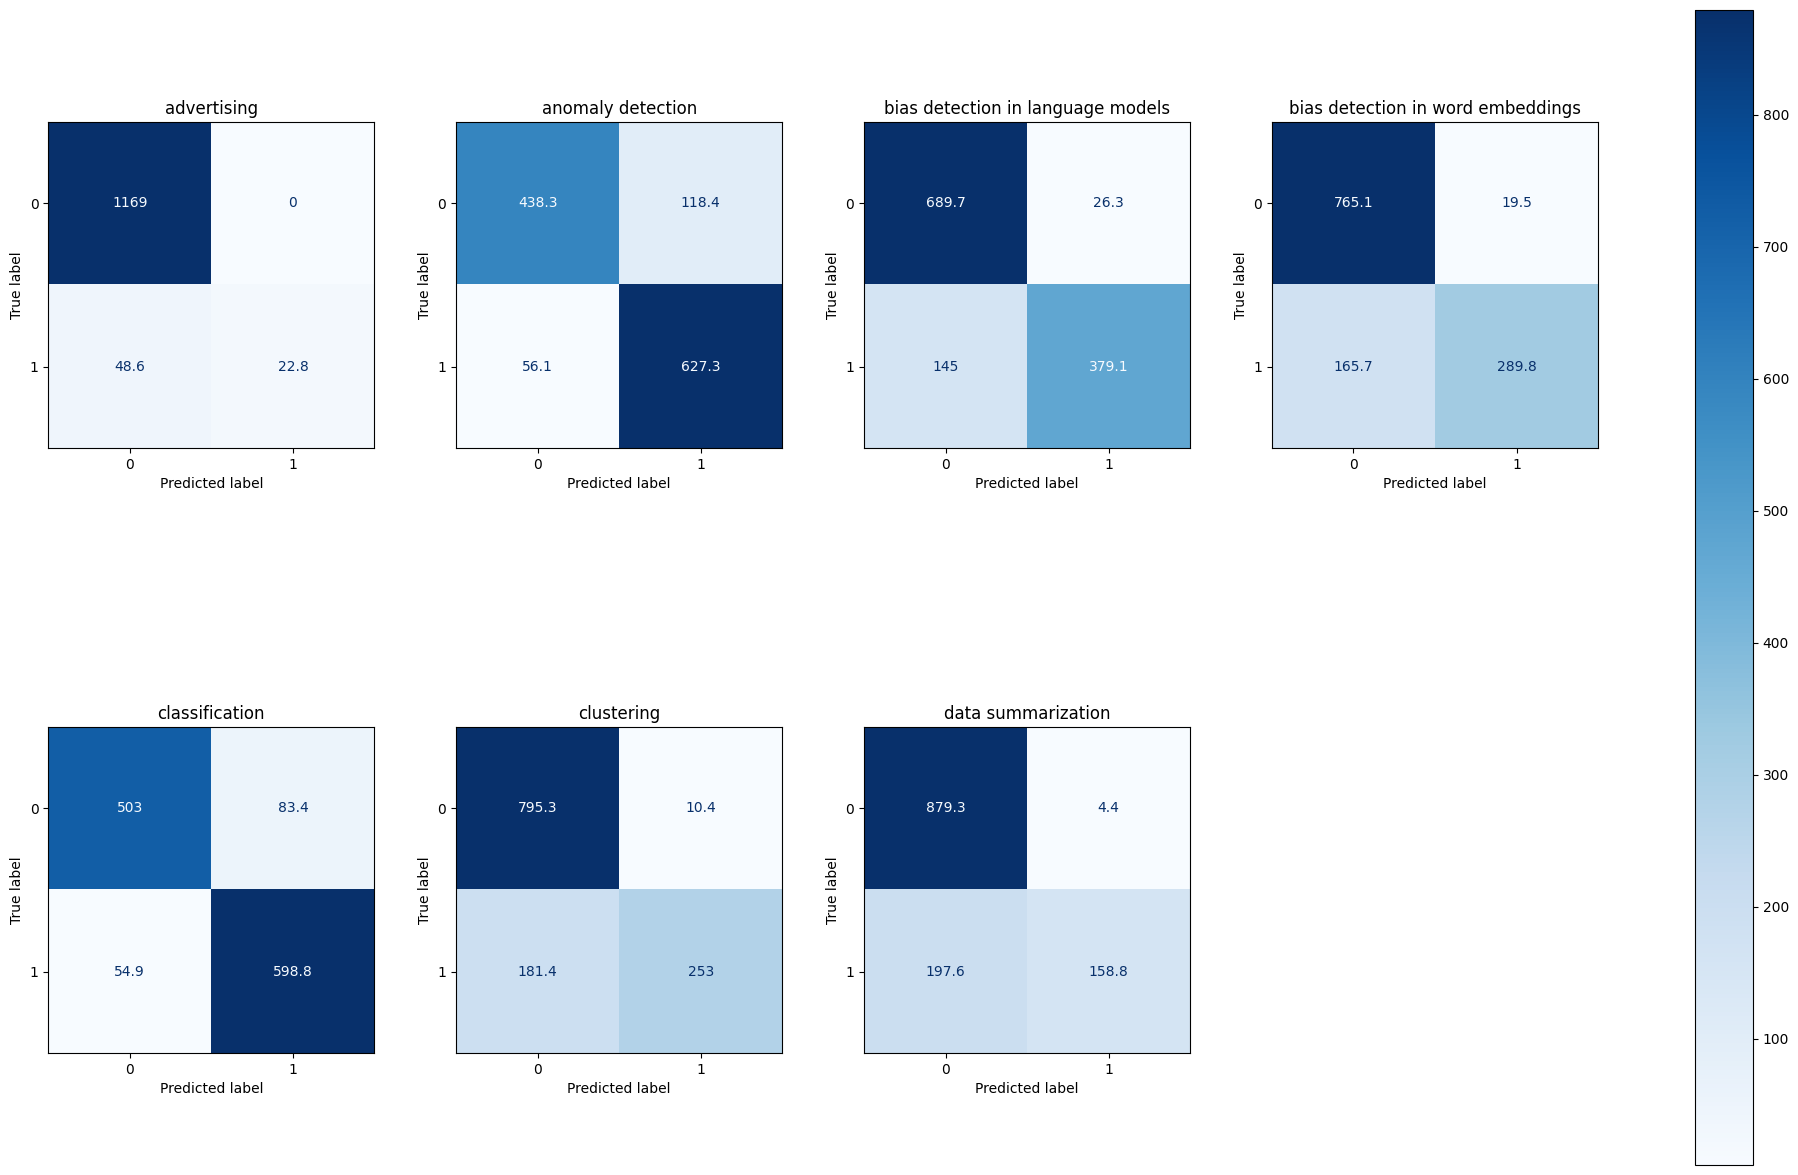

In [13]:
model = RandomForestClassifier()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, BinaryRelevance, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### LogisticRegression

Training on fold 1/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

Training on fold 2/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

Training on fold 3/10...


...

Training on fold 9/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

Training on fold 10/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

Precision: 0.5594405730630561
Recall Score: 0.21955658124492256
F1 Score: 0.31531277078092257
Hamming Loss: 0.2387929819264461


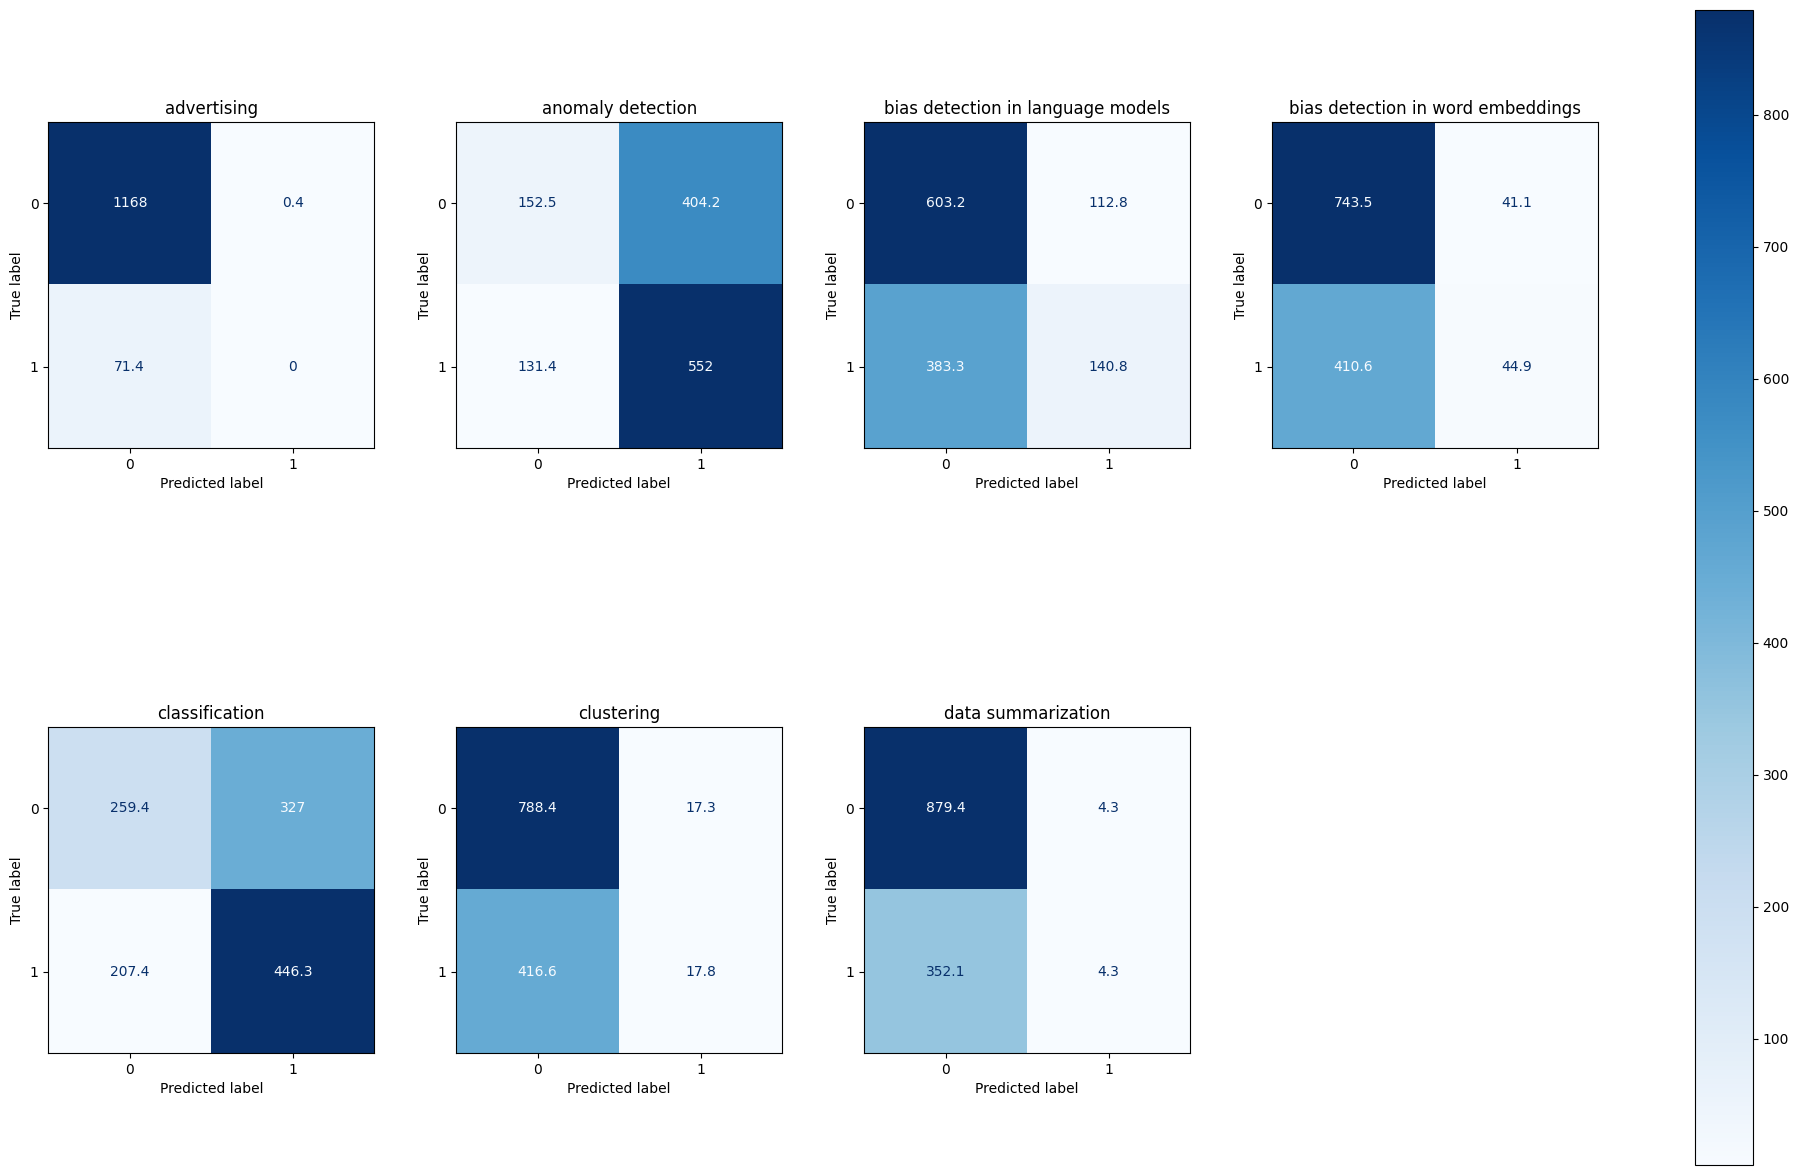

In [14]:
model = LogisticRegression()

prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, BinaryRelevance, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### Gaussian Naive Bayes

Training on fold 1/10...
Training on fold 2/10...
Training on fold 3/10...
Training on fold 4/10...
Training on fold 5/10...
Training on fold 6/10...
Training on fold 7/10...
Training on fold 8/10...
Training on fold 9/10...
Training on fold 10/10...
Precision: 0.14388554228547498
Recall Score: 0.2596977355451708
F1 Score: 0.1851203740806018
Hamming Loss: 0.5725124944263711


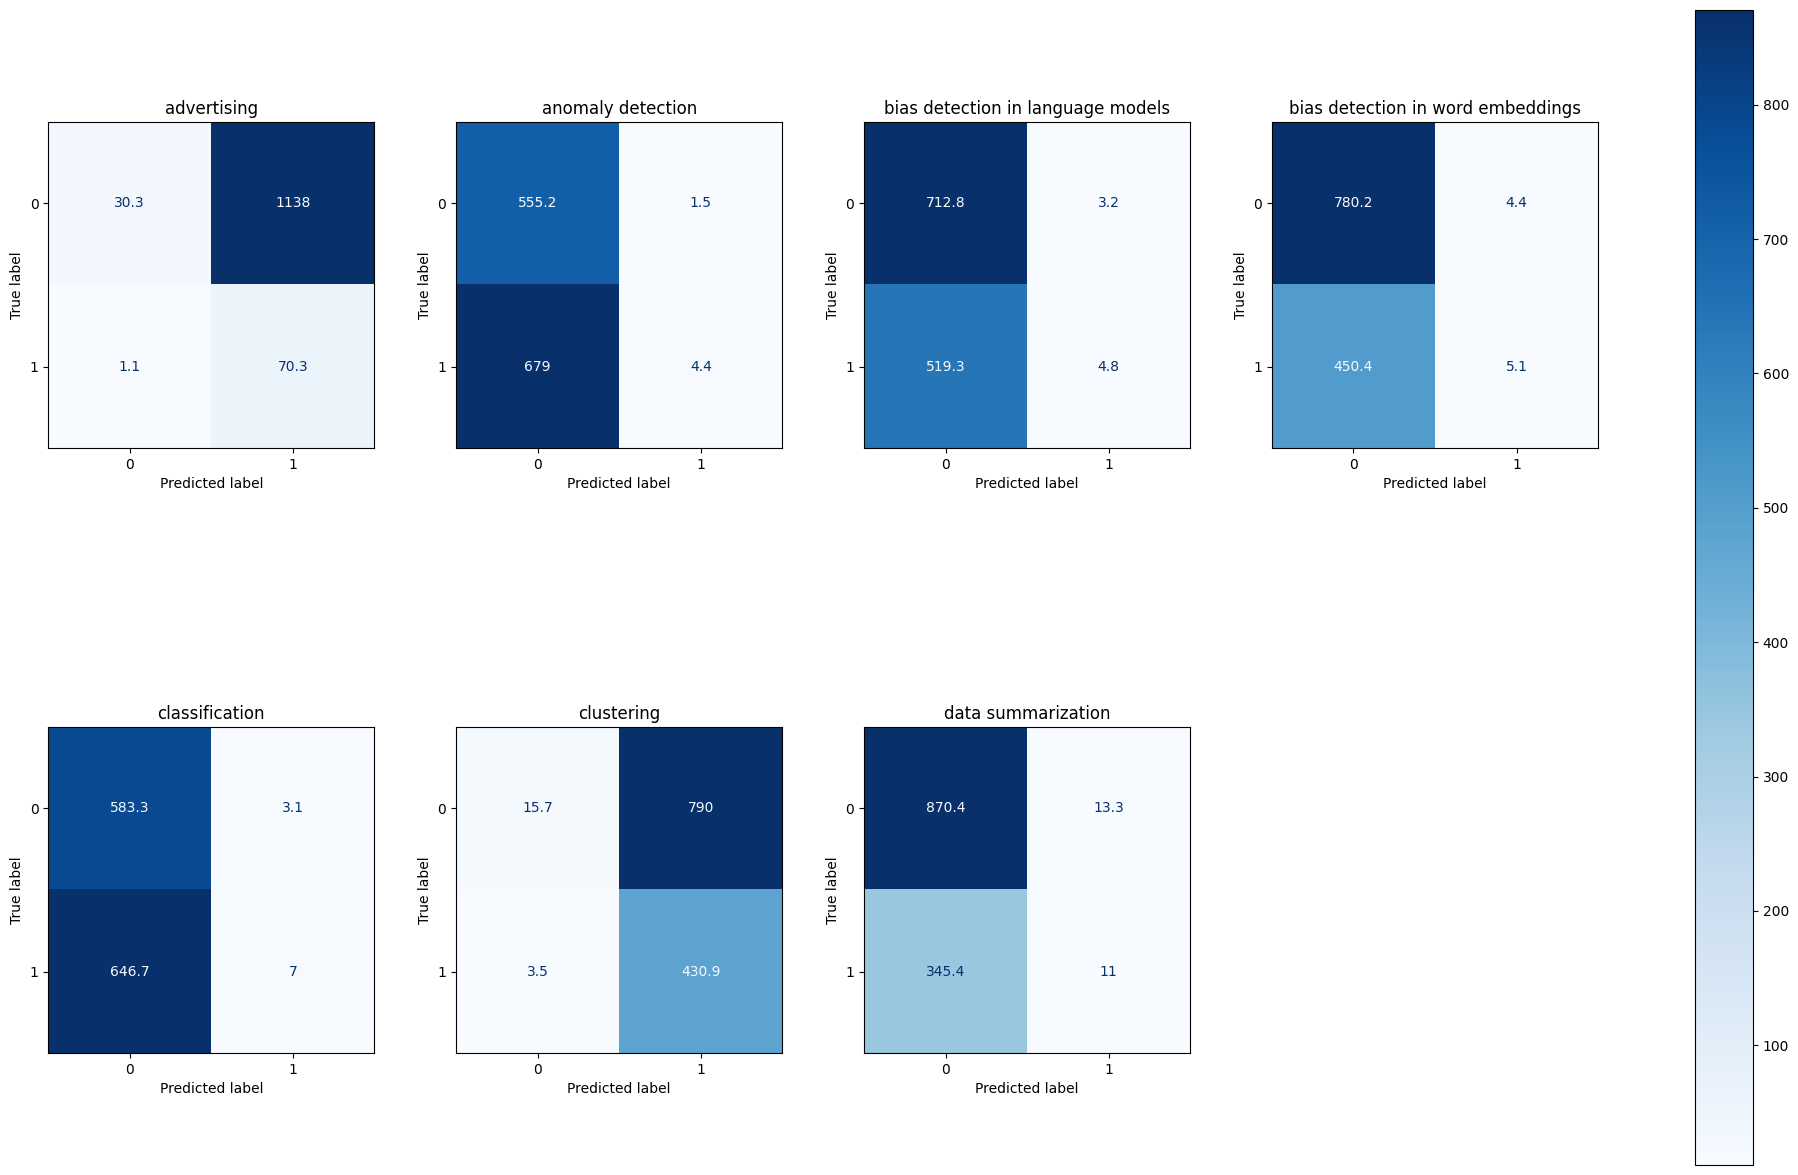

In [15]:
model = GaussianNB()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, BinaryRelevance, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### k-NearestNeighbors

Training on fold 1/10...
Training on fold 2/10...
Training on fold 3/10...
Training on fold 4/10...
Training on fold 5/10...
Training on fold 6/10...
Training on fold 7/10...
Training on fold 8/10...
Training on fold 9/10...
Training on fold 10/10...
Precision: 0.6799344350261477
Recall Score: 0.5022956129799521
F1 Score: 0.577692106557899
Hamming Loss: 0.18390606660761452


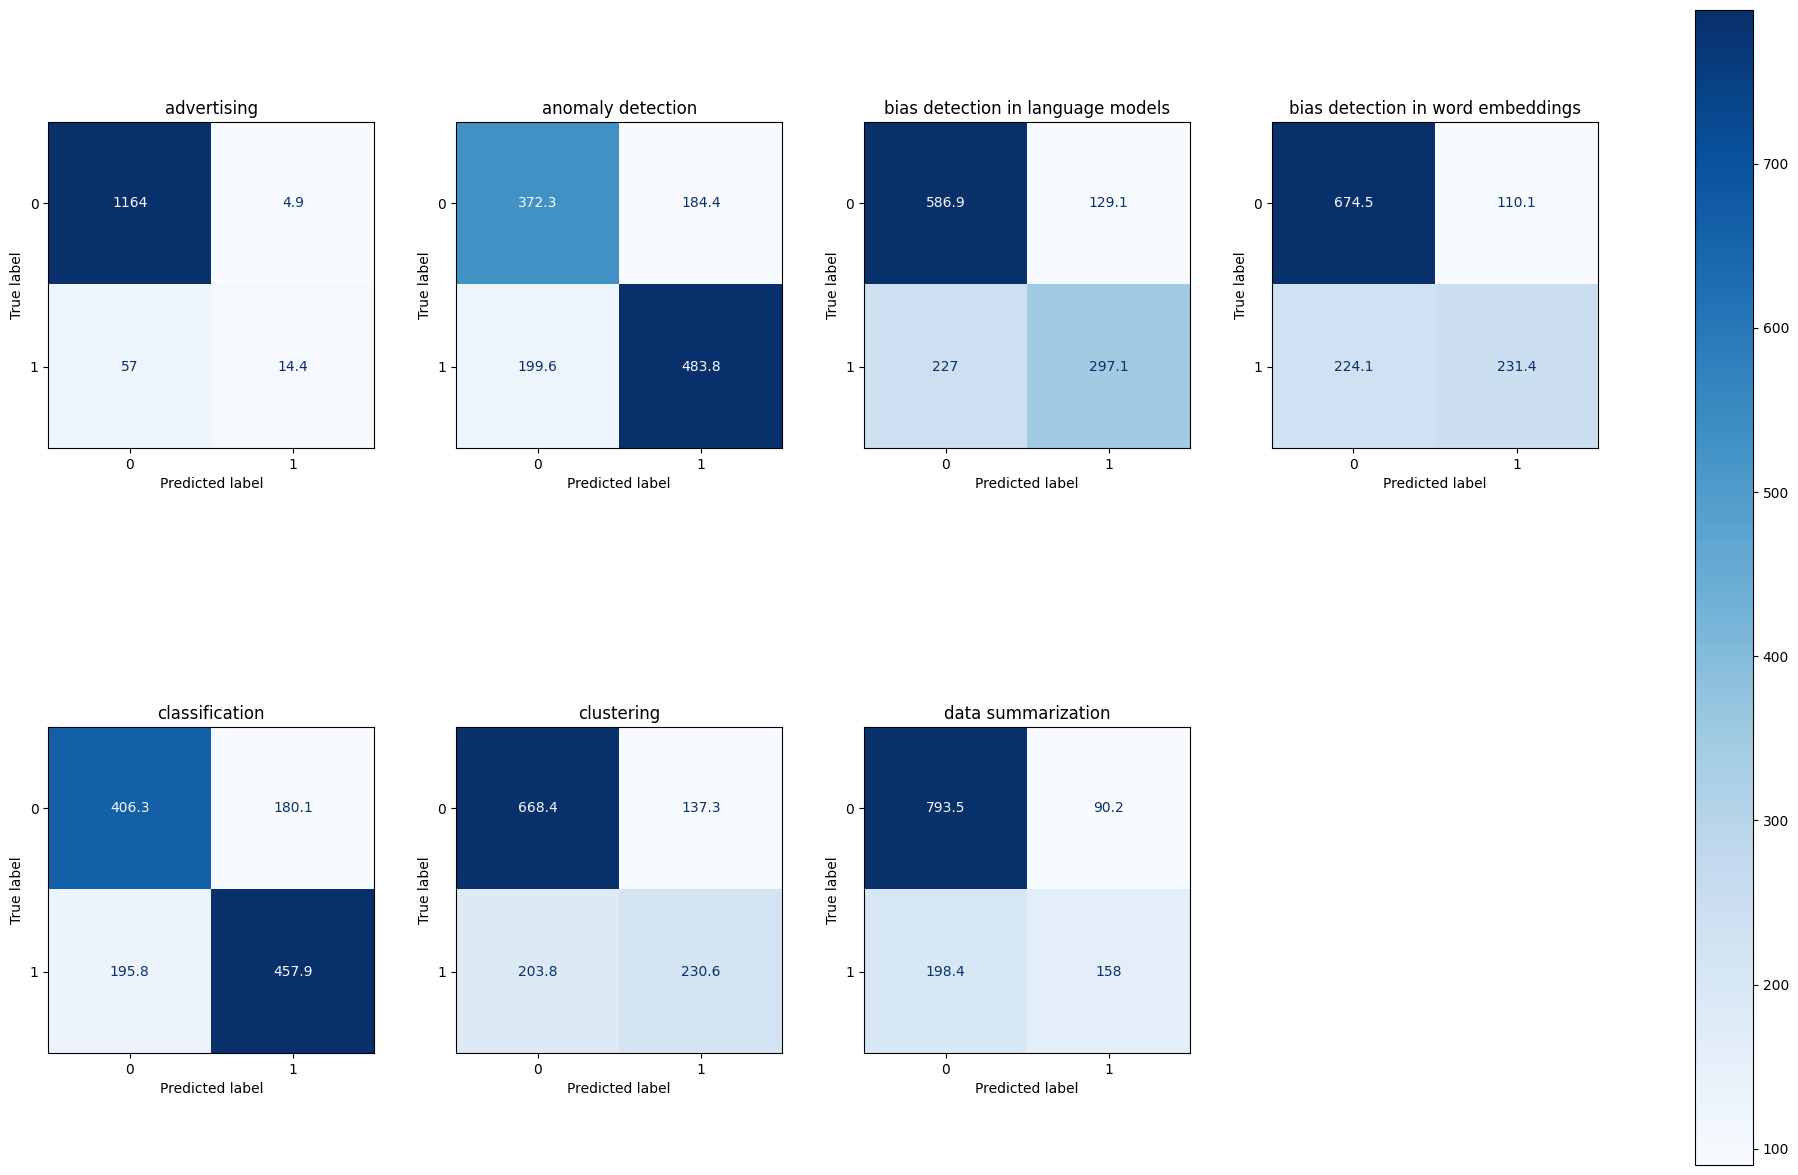

In [16]:
model = KNeighborsClassifier()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, BinaryRelevance, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### Decision Tree

Training on fold 1/10...
Training on fold 2/10...
Training on fold 3/10...
Training on fold 4/10...
Training on fold 5/10...
Training on fold 6/10...
Training on fold 7/10...
Training on fold 8/10...
Training on fold 9/10...
Training on fold 10/10...
Precision: 0.770944539181113
Recall Score: 0.7807397744709651
F1 Score: 0.7757699982162517
Hamming Loss: 0.11301795758243474


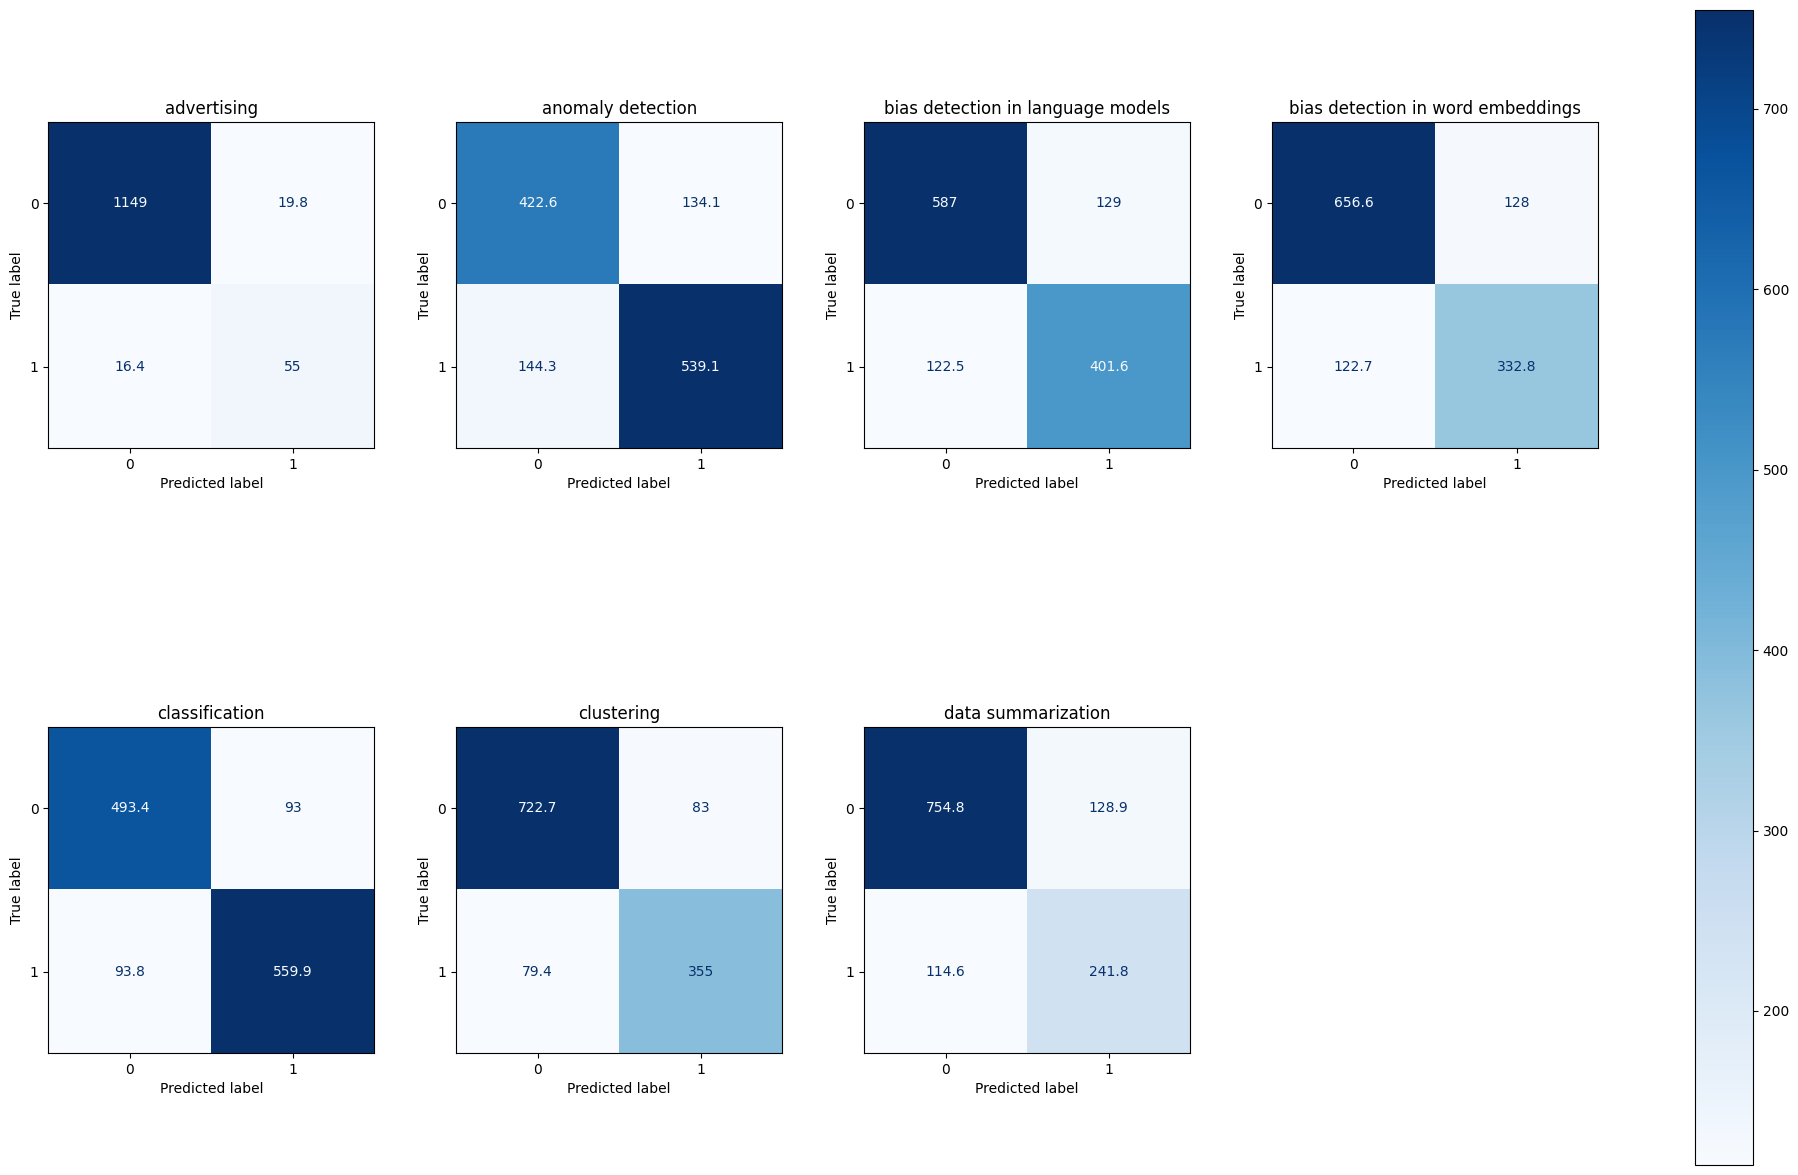

In [17]:
model = DecisionTreeClassifier()

prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, BinaryRelevance, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### Support Vector Machine

Training on fold 1/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Des

Training on fold 2/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Des

Training on fold 3/10...


...

Training on fold 9/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Des

Training on fold 10/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Des

Precision: 0.3729808874727835
Recall Score: 0.4014289077082342
F1 Score: 0.385058871059255
Hamming Loss: 0.3202157069360937


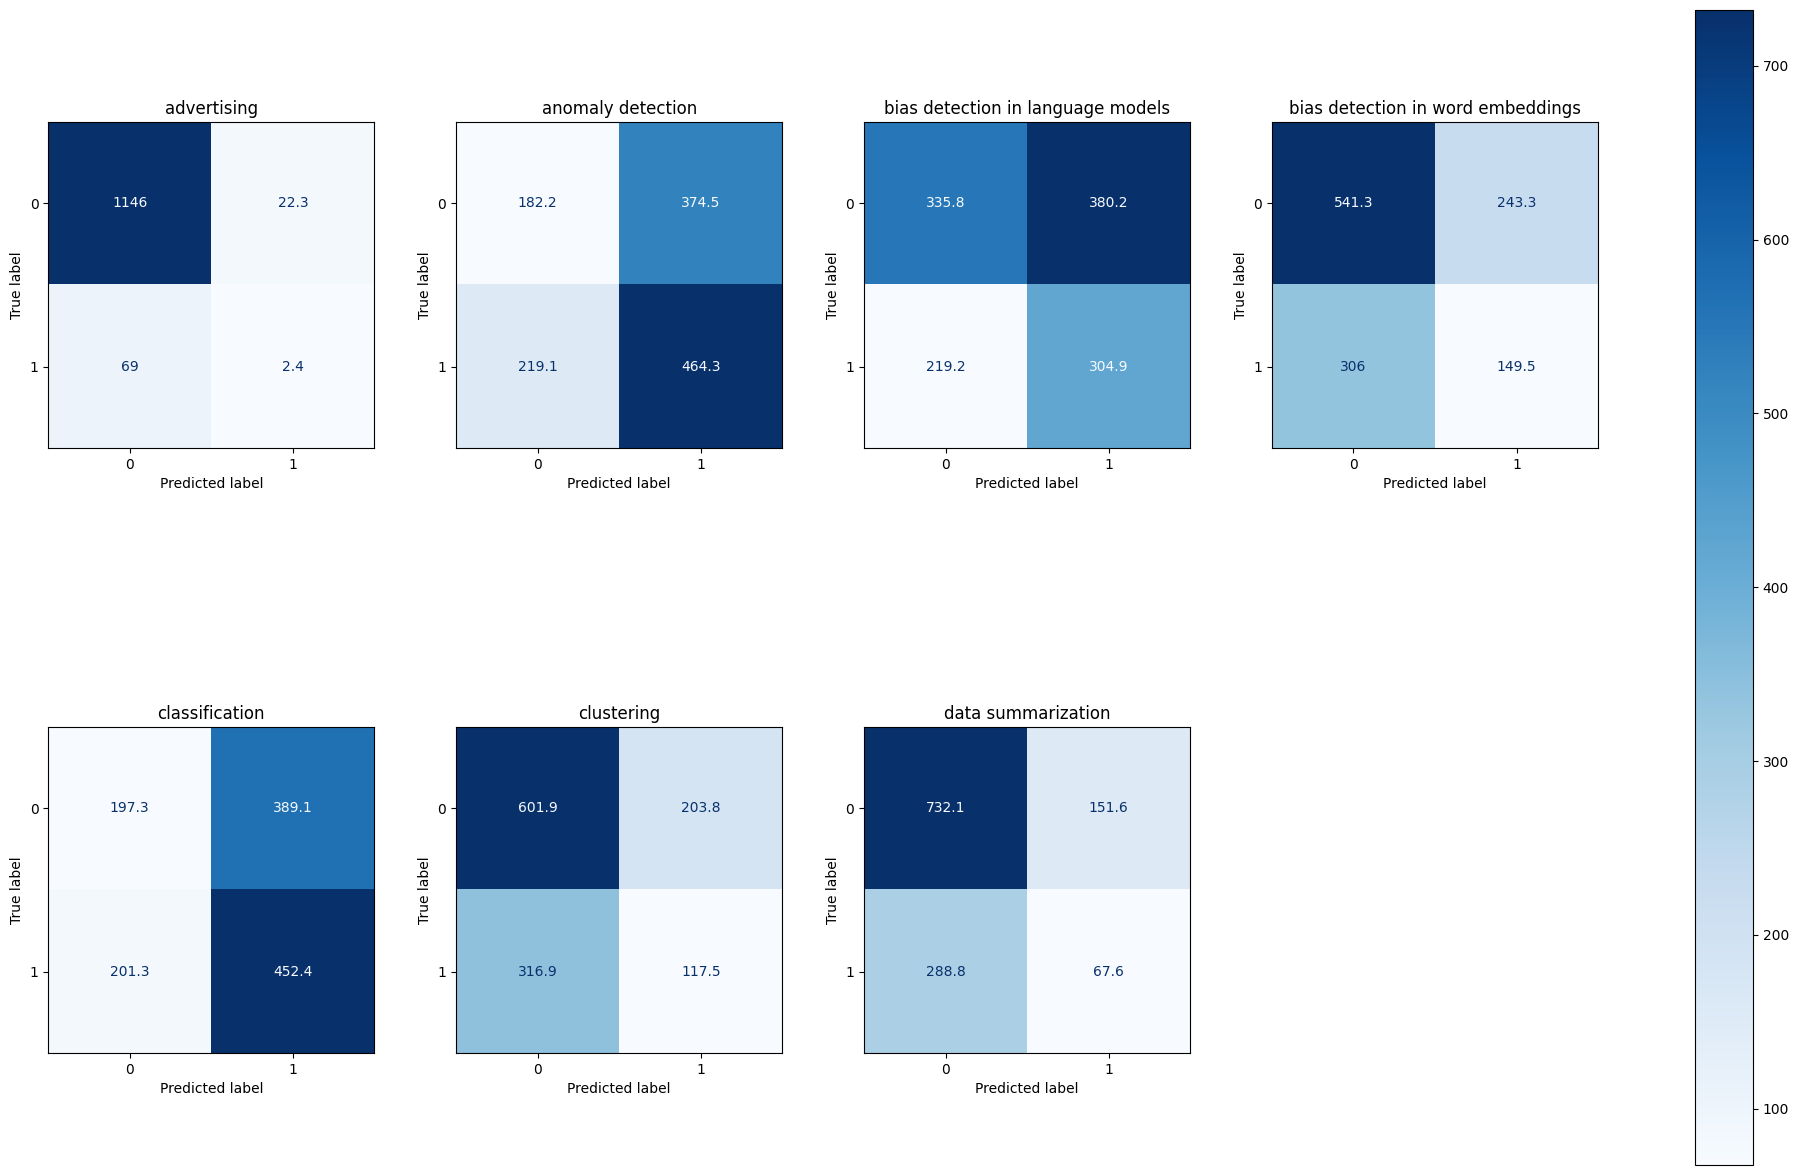

In [18]:
model = LinearSVC()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, BinaryRelevance, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

### **ClassifierChain**

#### RandomForest

Training on fold 1/10...
Training on fold 2/10...
Training on fold 3/10...
Training on fold 4/10...
Training on fold 5/10...
Training on fold 6/10...
Training on fold 7/10...
Training on fold 8/10...
Training on fold 9/10...
Training on fold 10/10...
Precision: 0.808135327823911
Recall Score: 0.7309206452564958
F1 Score: 0.7674542705397975
Hamming Loss: 0.11089663192854557


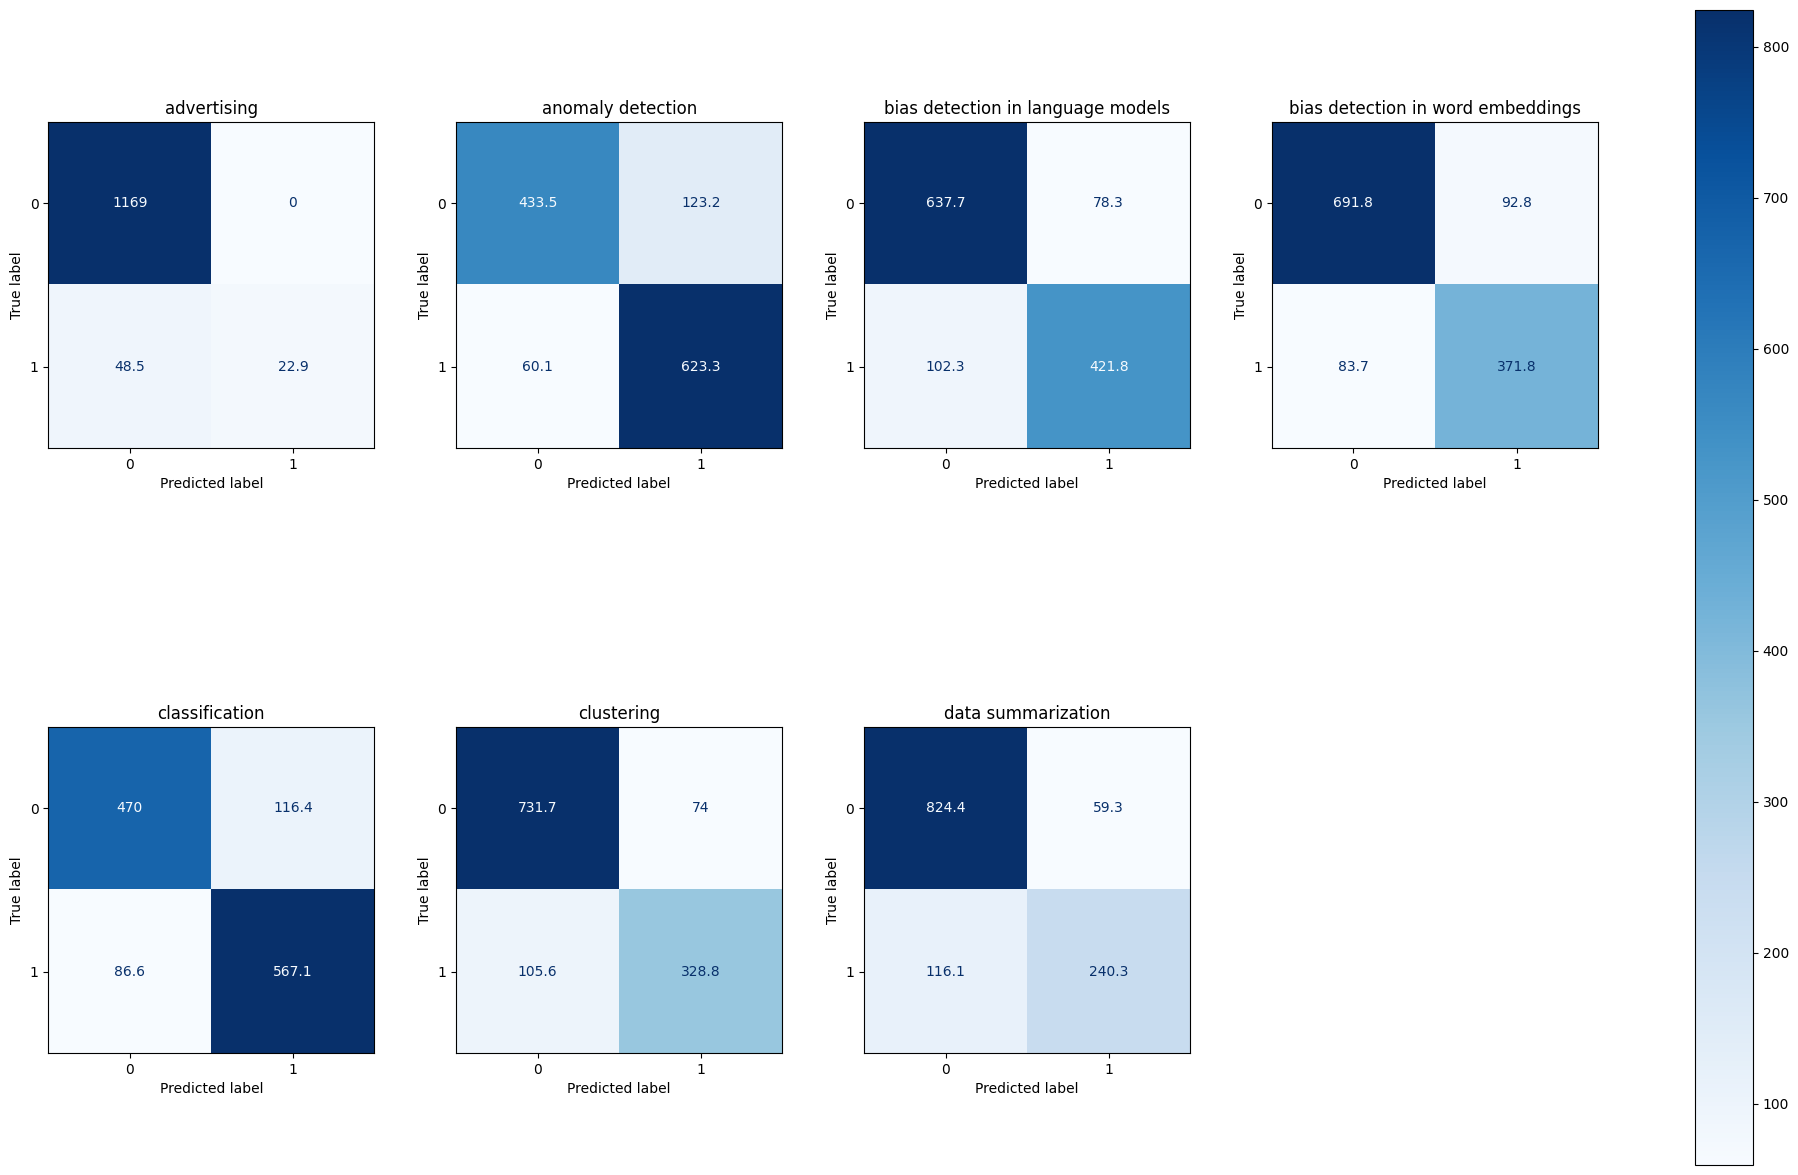

In [19]:
model = RandomForestClassifier()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, ClassifierChain, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### LogisticRegression

Training on fold 1/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

Training on fold 2/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

Training on fold 3/10...


...

Training on fold 9/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

Training on fold 10/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

Precision: 0.560527167767251
Recall Score: 0.22027253331065122
F1 Score: 0.3161814196029476
Hamming Loss: 0.23857241618561834


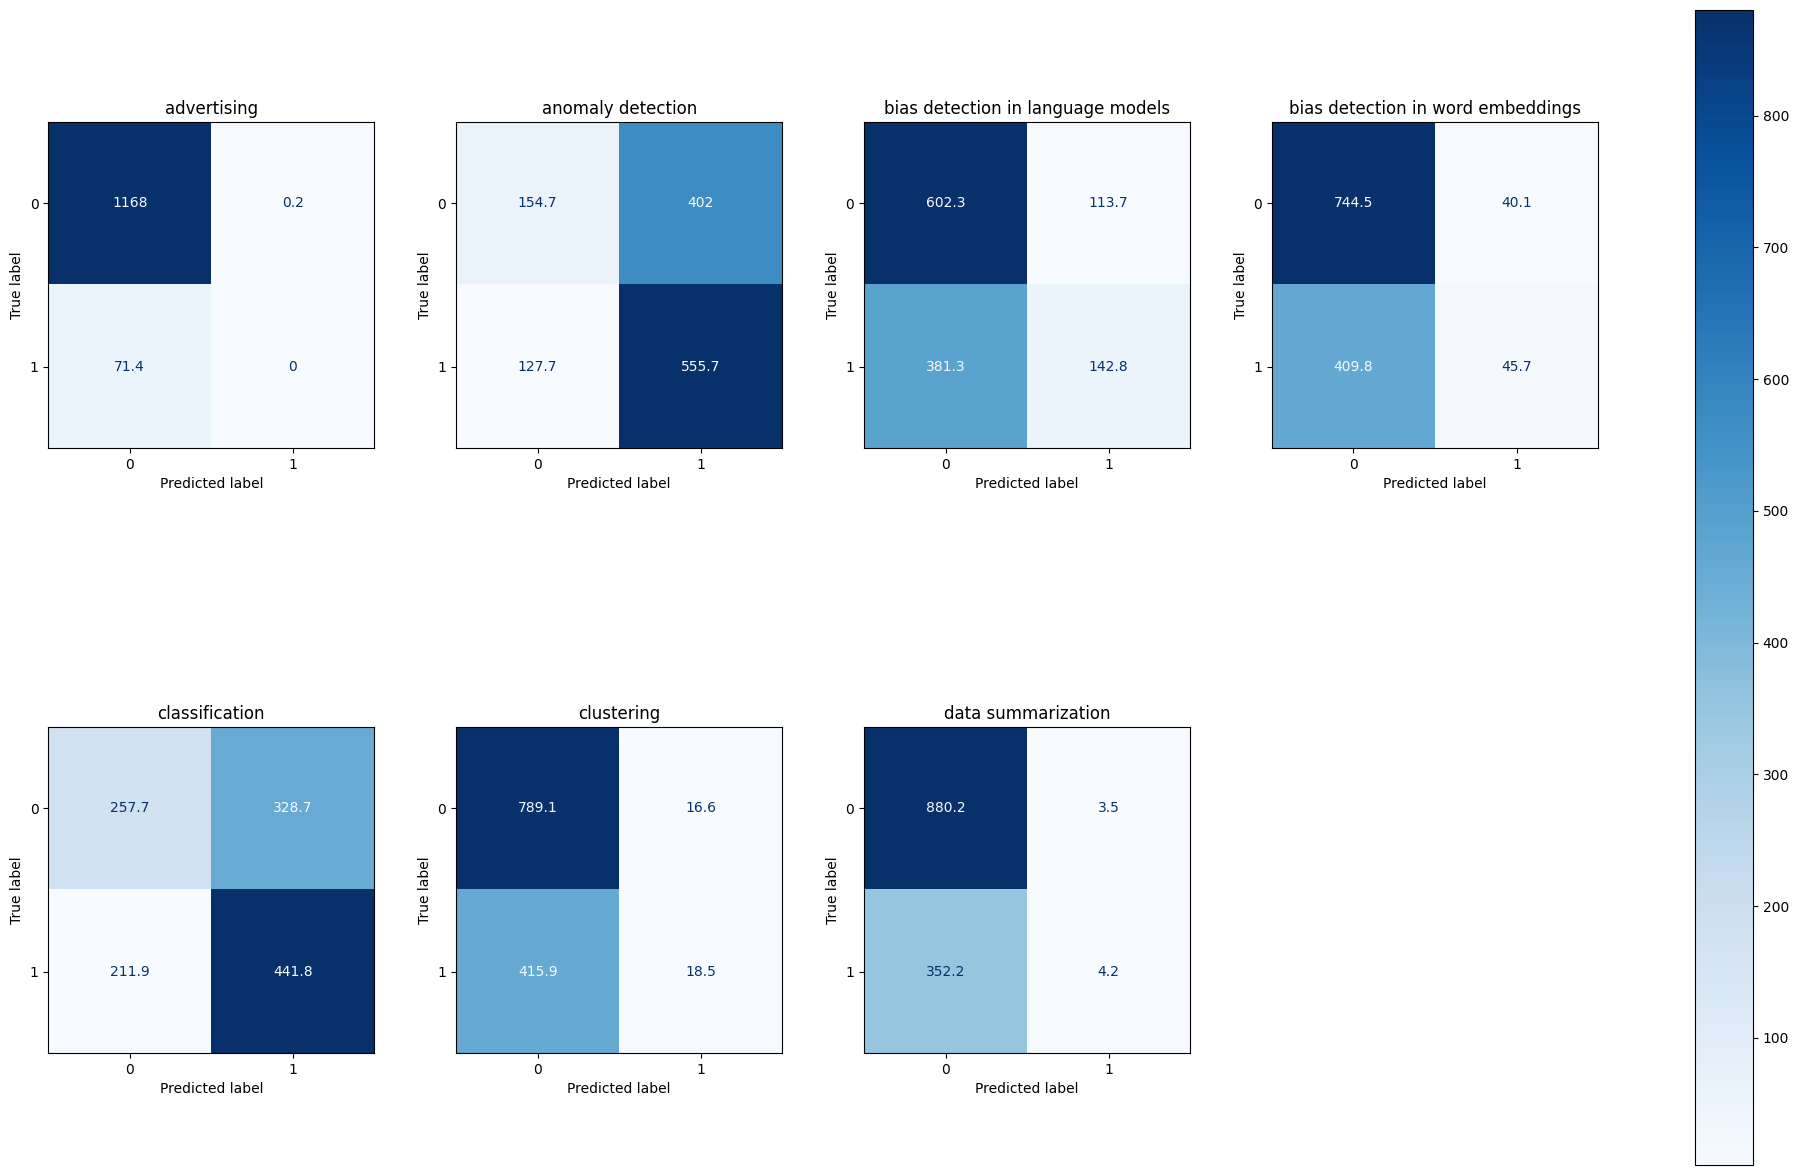

In [20]:
model = LogisticRegression()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, ClassifierChain, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

####2.4.2.3) Gaussian Naive Bayes

Training on fold 1/10...
Training on fold 2/10...
Training on fold 3/10...
Training on fold 4/10...
Training on fold 5/10...
Training on fold 6/10...
Training on fold 7/10...
Training on fold 8/10...
Training on fold 9/10...
Training on fold 10/10...
Precision: 0.14488115201724072
Recall Score: 0.26876478727799286
F1 Score: 0.18816088622195187
Hamming Loss: 0.5799409720208829


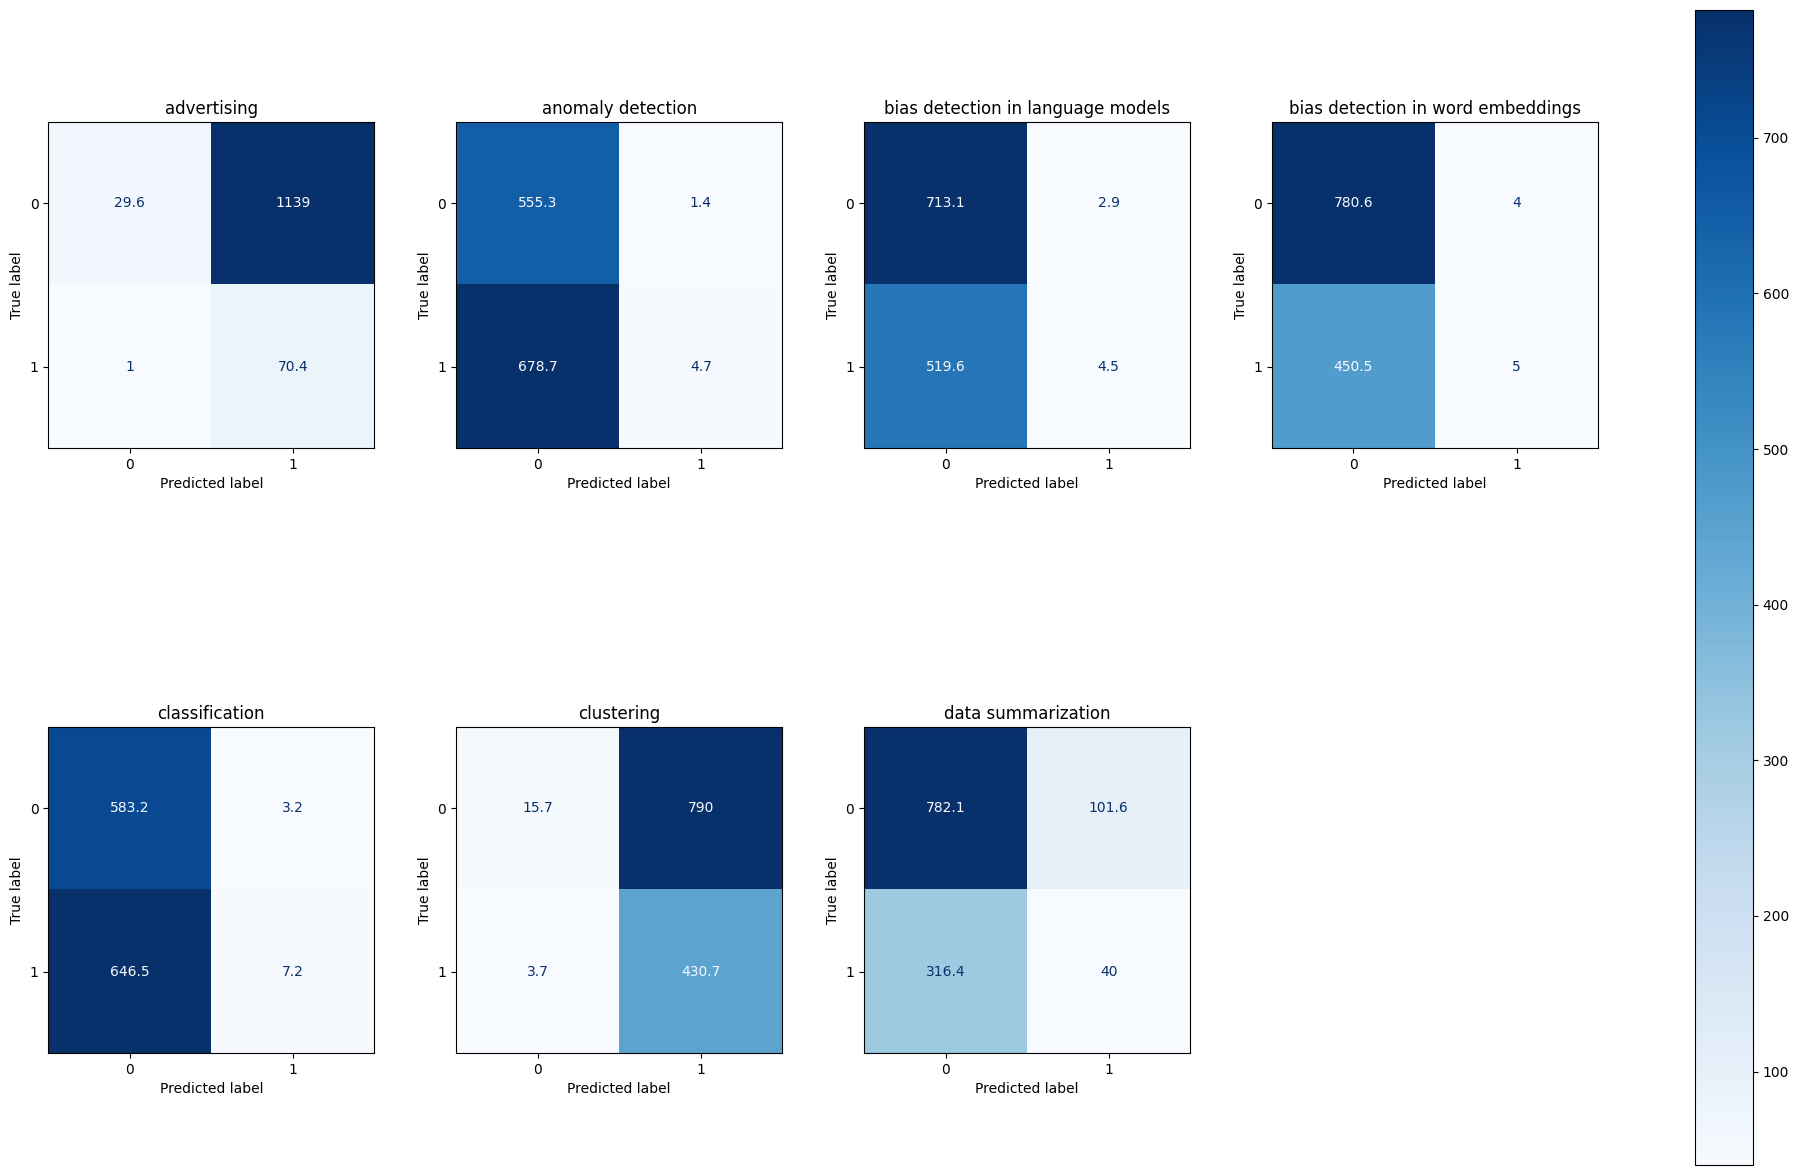

In [21]:
model = GaussianNB()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, ClassifierChain, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### k-NearestNeighbors

Training on fold 1/10...
Training on fold 2/10...
Training on fold 3/10...
Training on fold 4/10...
Training on fold 5/10...
Training on fold 6/10...
Training on fold 7/10...
Training on fold 8/10...
Training on fold 9/10...
Training on fold 10/10...
Precision: 0.6817566261183491
Recall Score: 0.49964611014342664
F1 Score: 0.5765737431358595
Hamming Loss: 0.18369860764251994


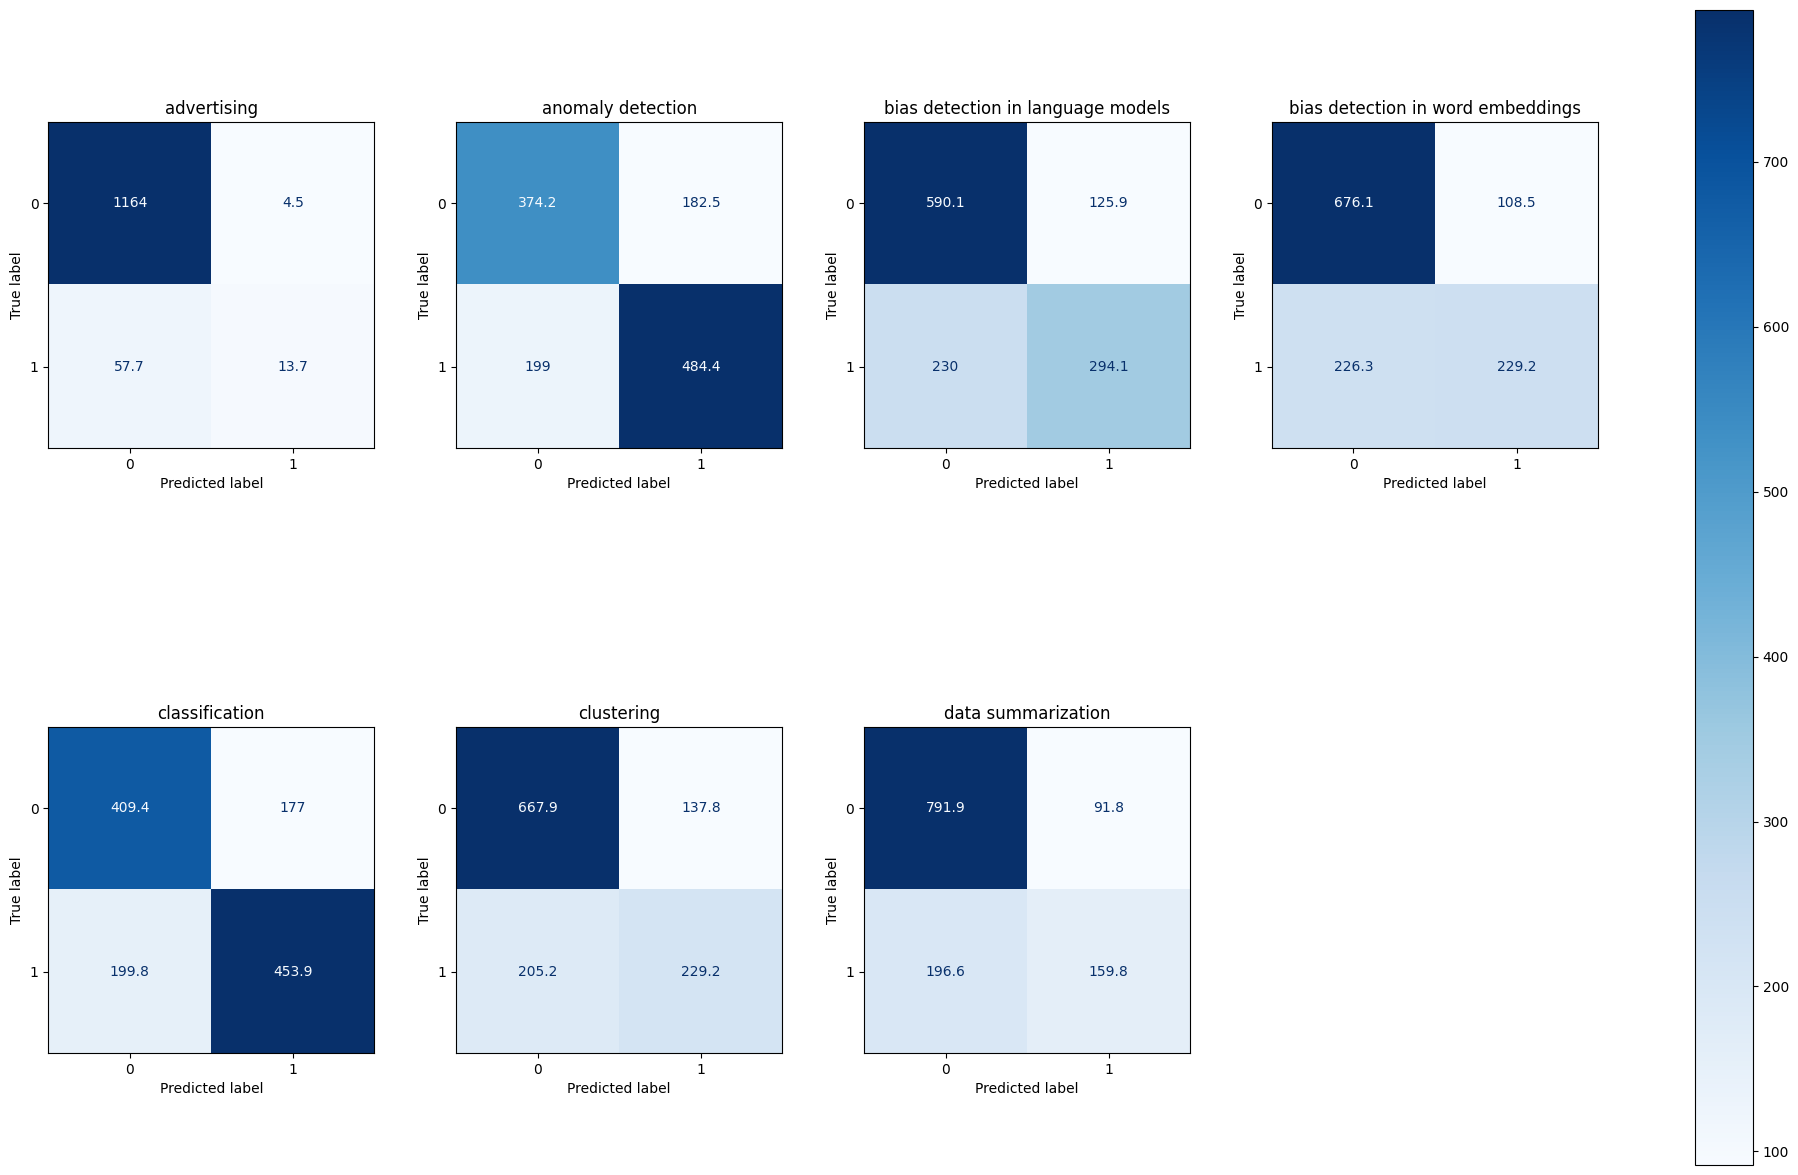

In [22]:
model = KNeighborsClassifier()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, ClassifierChain, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### Decision Tree

Training on fold 1/10...
Training on fold 2/10...
Training on fold 3/10...
Training on fold 4/10...
Training on fold 5/10...
Training on fold 6/10...
Training on fold 7/10...
Training on fold 8/10...
Training on fold 9/10...
Training on fold 10/10...
Precision: 0.7012412683350989
Recall Score: 0.7012696593533985
F1 Score: 0.7011182178934788
Hamming Loss: 0.1497186017239759


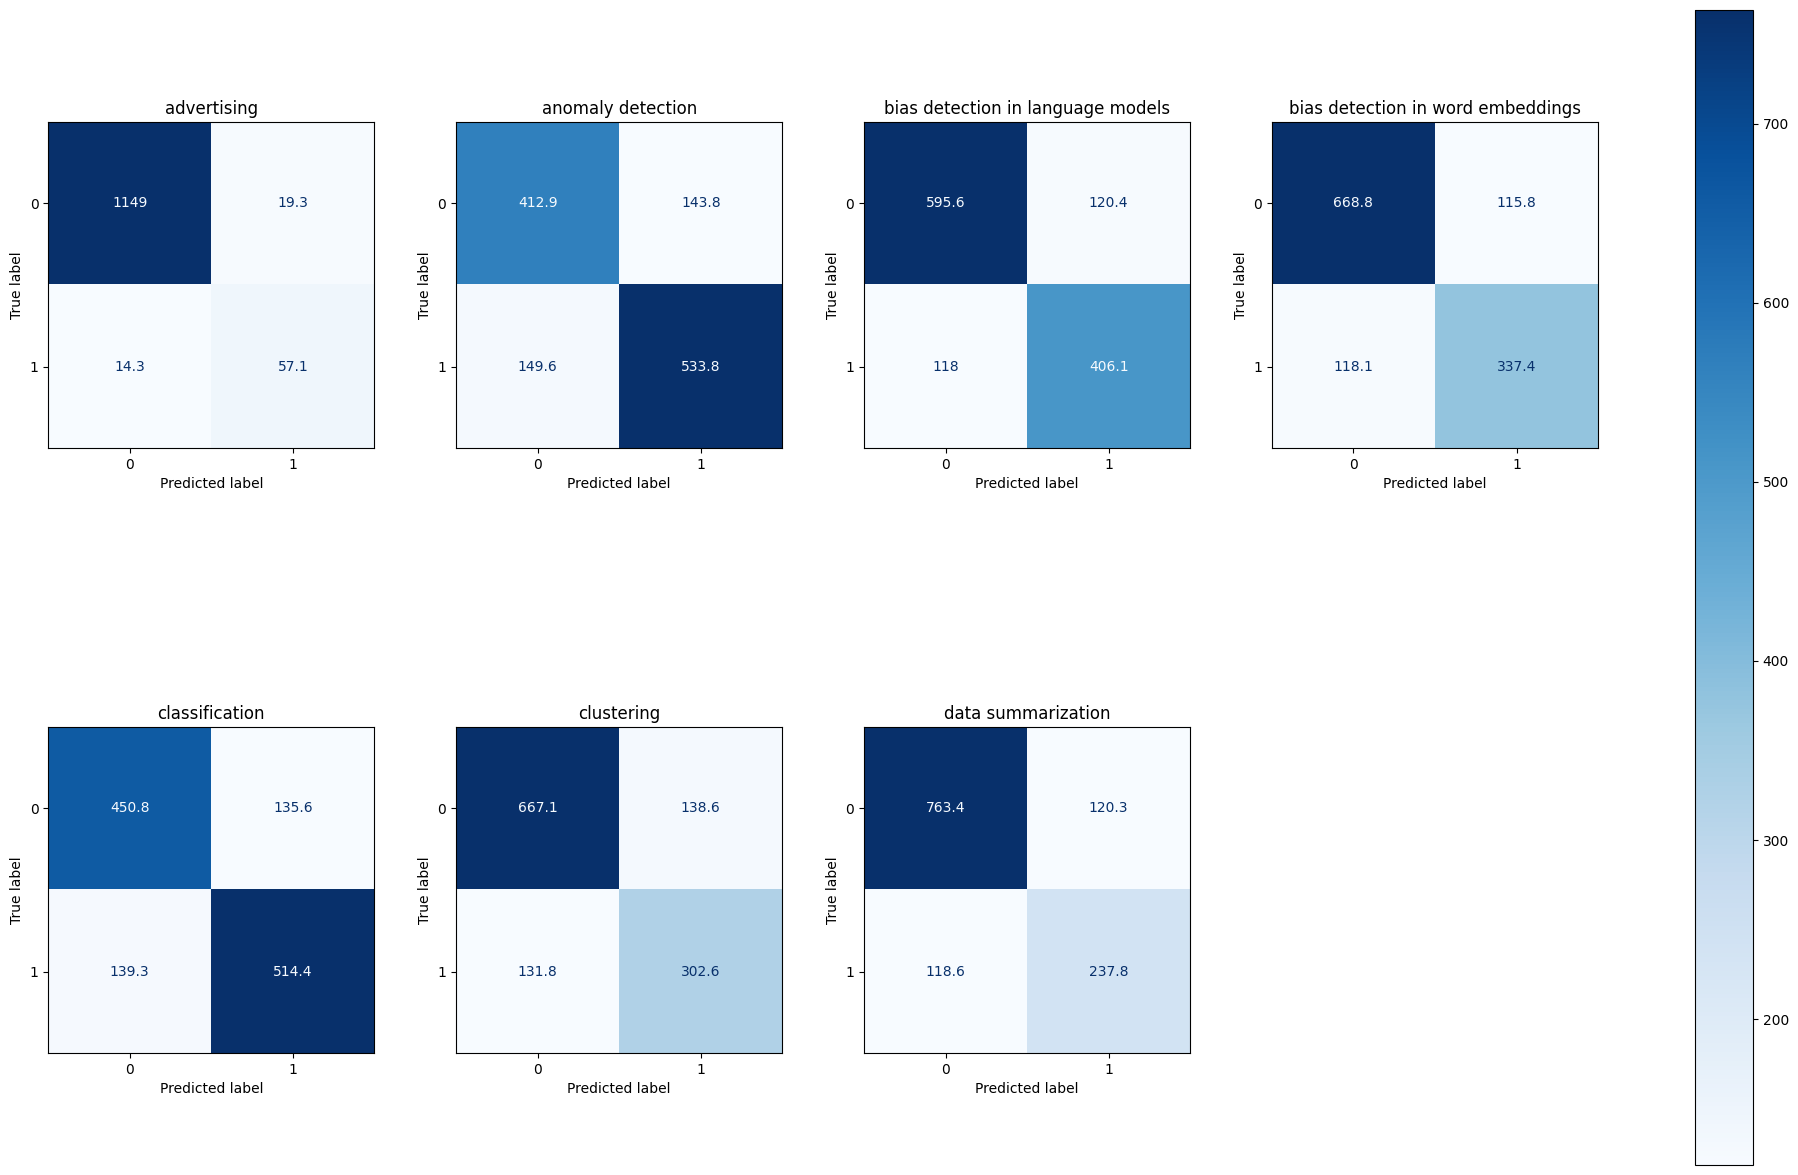

In [23]:
model = DecisionTreeClassifier()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, ClassifierChain, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### Support Vector Machine

Training on fold 1/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Des

Training on fold 2/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Des

Training on fold 3/10...


...

Training on fold 9/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Des

Training on fold 10/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\pc\Des

Precision: 0.3648984160635342
Recall Score: 0.38328820256645013
F1 Score: 0.3711639931796741
Hamming Loss: 0.3228923084921109


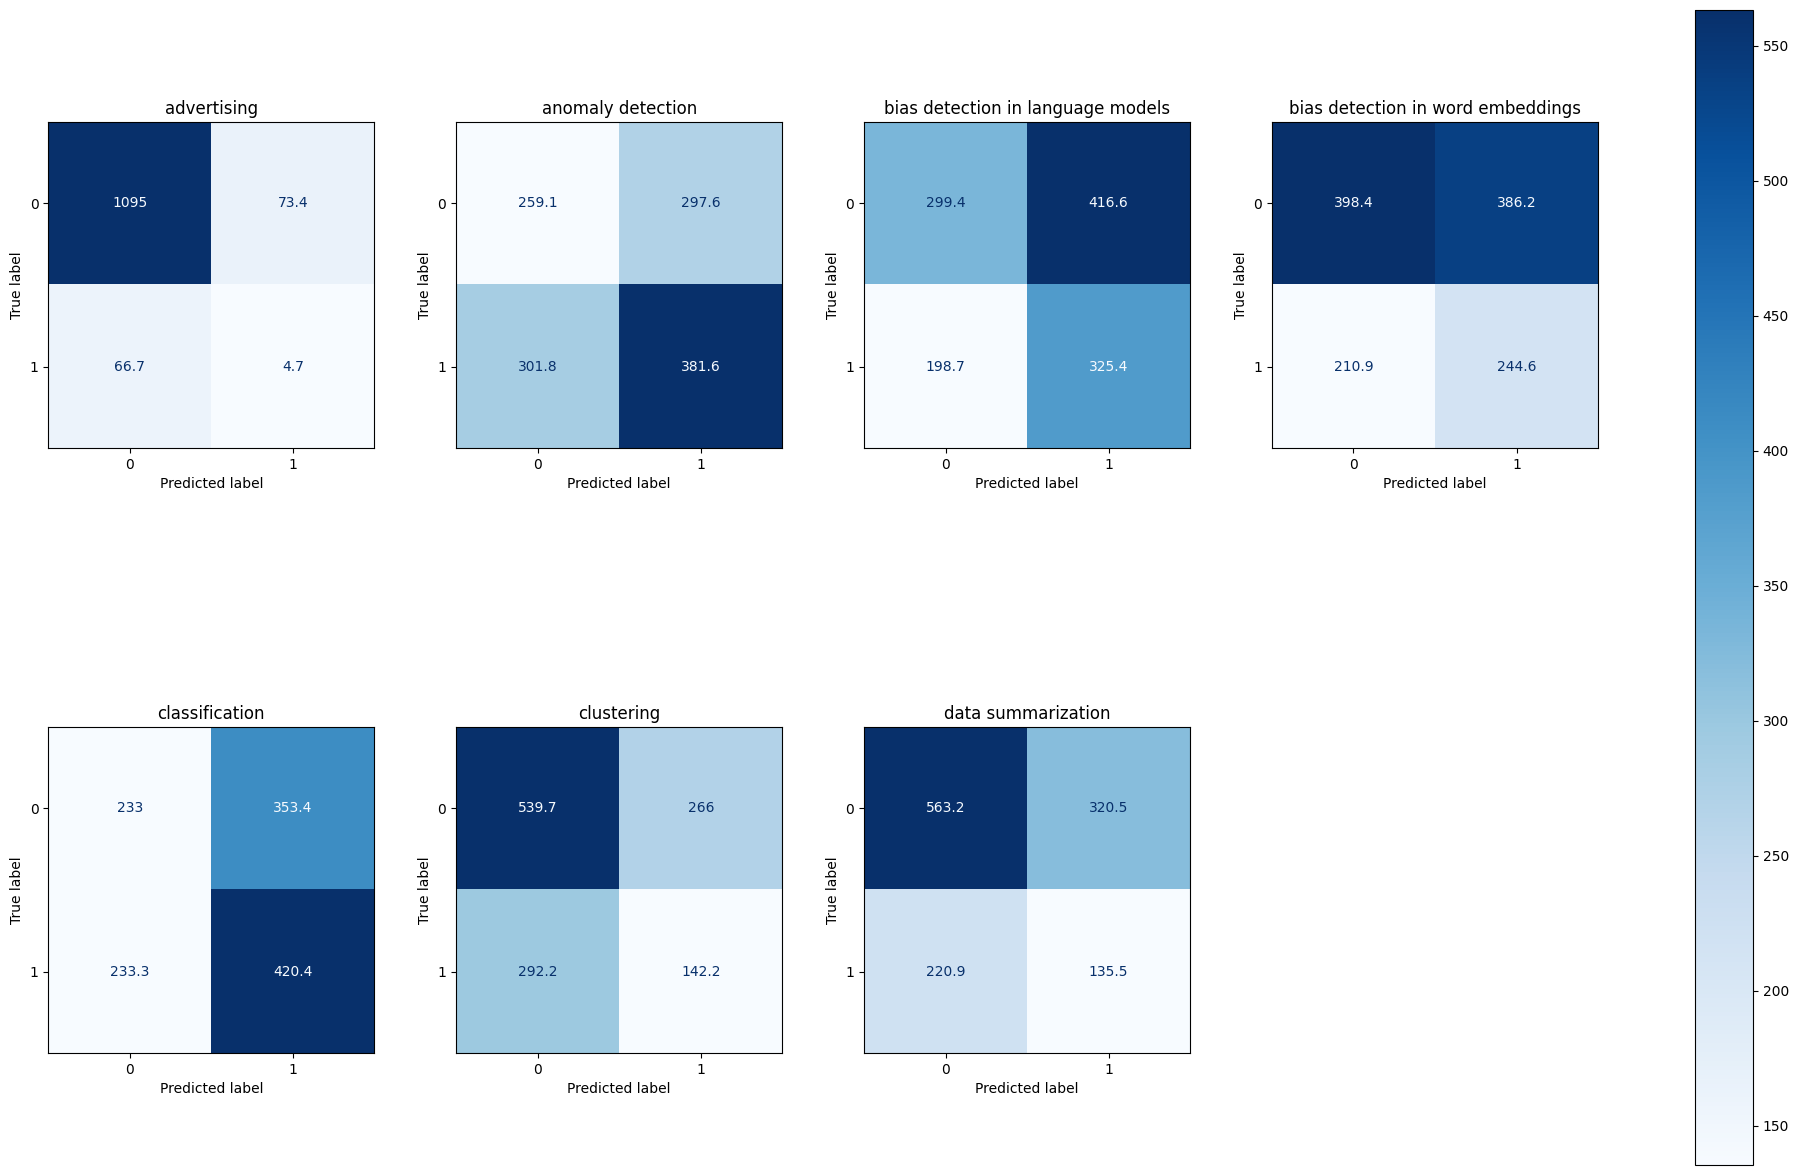

In [24]:
model = LinearSVC()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, ClassifierChain, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

### **LabelPowerset**

#### RandomForest

Training on fold 1/10...
Training on fold 2/10...
Training on fold 3/10...
Training on fold 4/10...
Training on fold 5/10...
Training on fold 6/10...
Training on fold 7/10...
Training on fold 8/10...
Training on fold 9/10...
Training on fold 10/10...
Precision: 0.9004087351398056
Recall Score: 0.7856855334036297
F1 Score: 0.8391058523556383
Hamming Loss: 0.07544644017571678


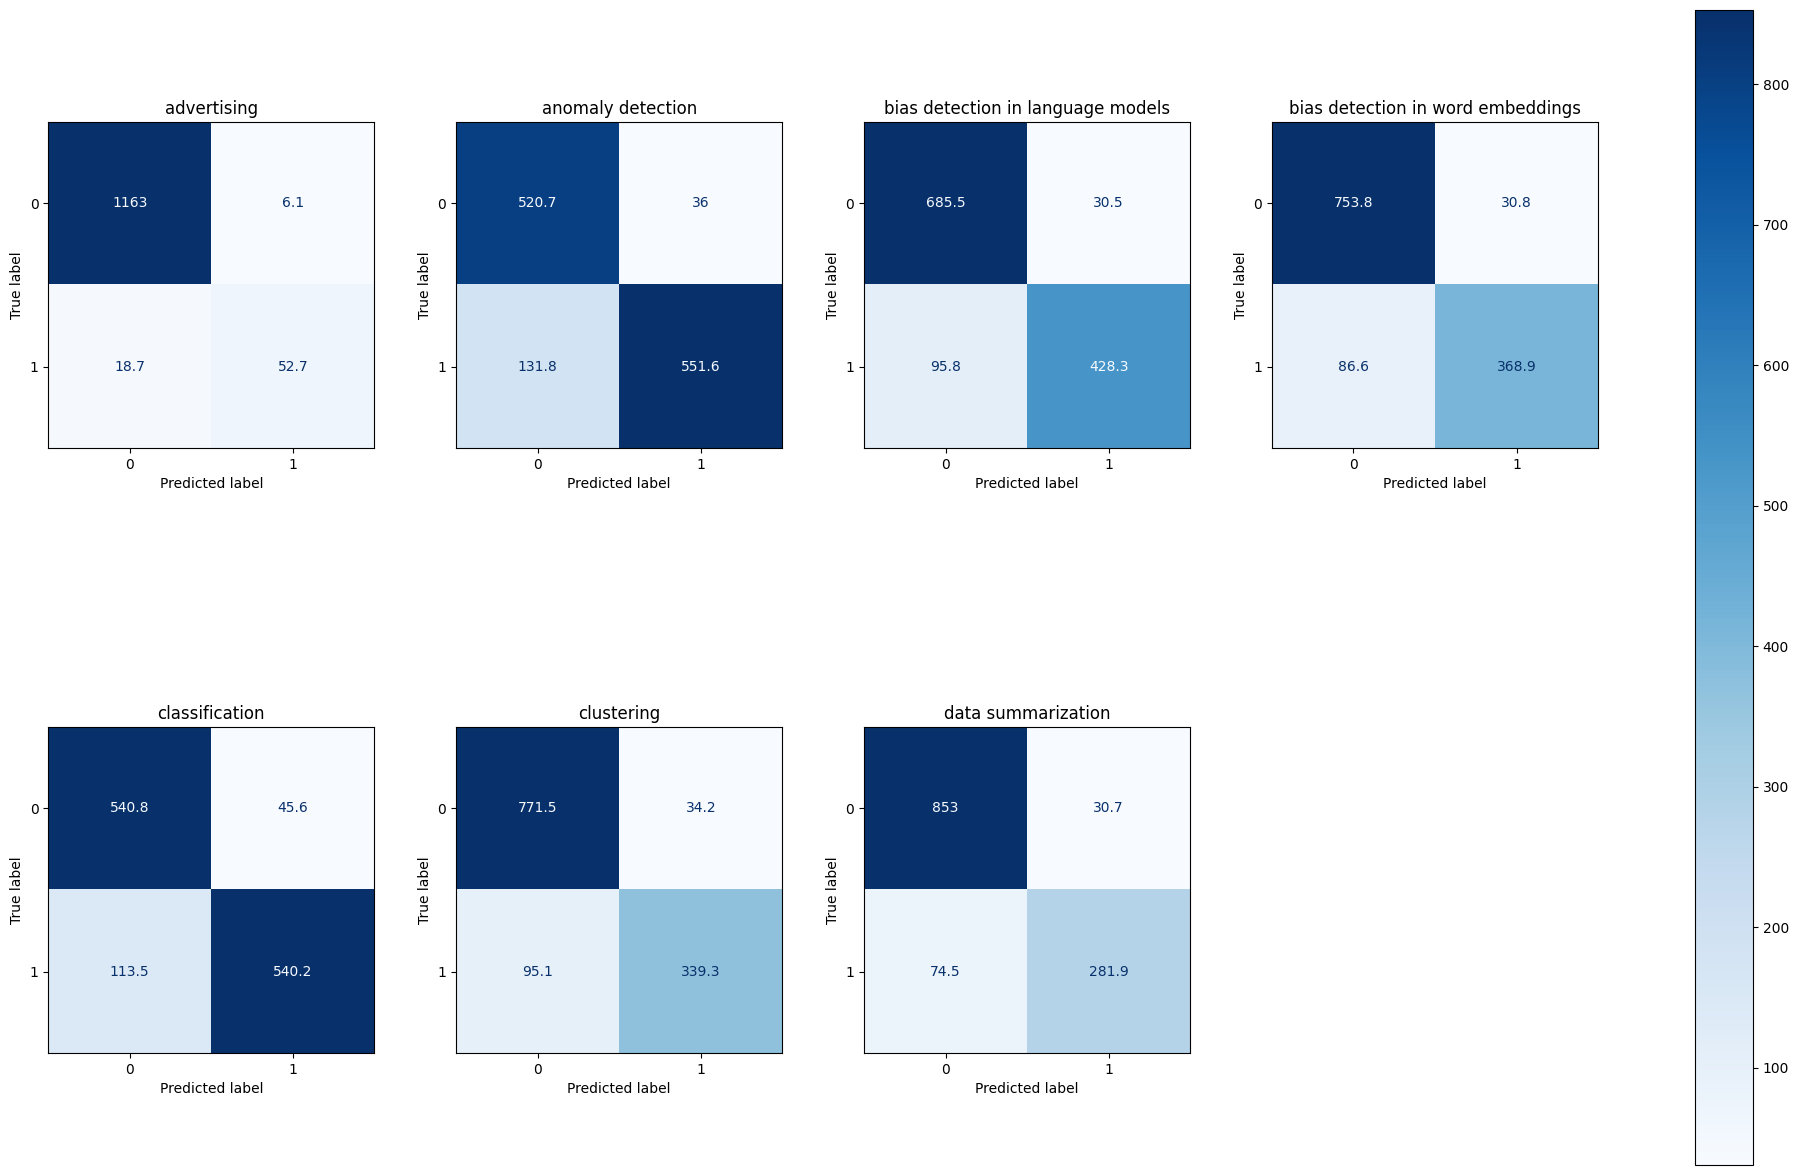

In [25]:
model = RandomForestClassifier()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, LabelPowerset, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### LogisticRegression

Training on fold 1/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training on fold 2/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training on fold 3/10...


...

Training on fold 9/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training on fold 10/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Precision: 0.47928565695545194
Recall Score: 0.4287438350242533
F1 Score: 0.45252640414941786
Hamming Loss: 0.2597560500116971


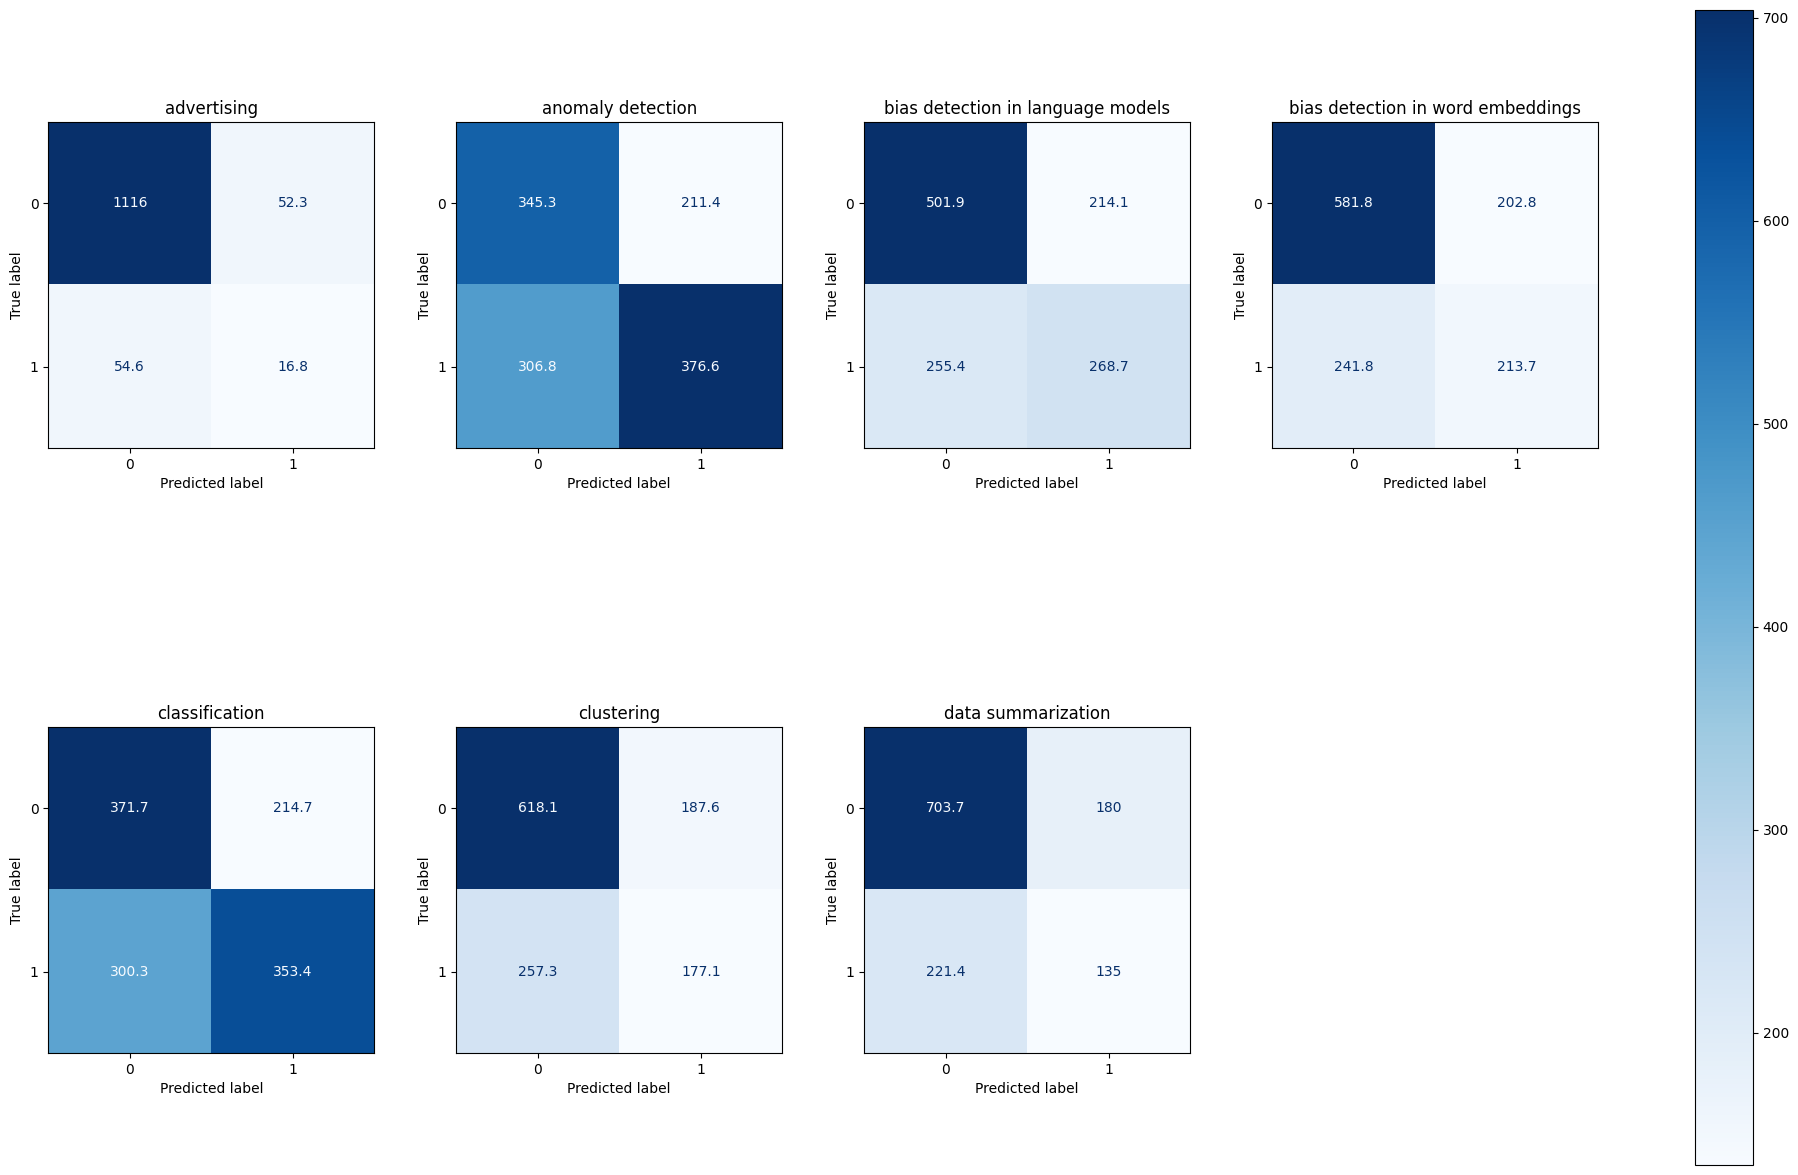

In [26]:
model = LogisticRegression()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, LabelPowerset, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### Gaussian Naive Bayes

Training on fold 1/10...
Training on fold 2/10...
Training on fold 3/10...
Training on fold 4/10...
Training on fold 5/10...
Training on fold 6/10...
Training on fold 7/10...
Training on fold 8/10...
Training on fold 9/10...
Training on fold 10/10...
Precision: 0.3450970246258246
Recall Score: 0.4647152017977857
F1 Score: 0.39590340023264114
Hamming Loss: 0.3546517331736393


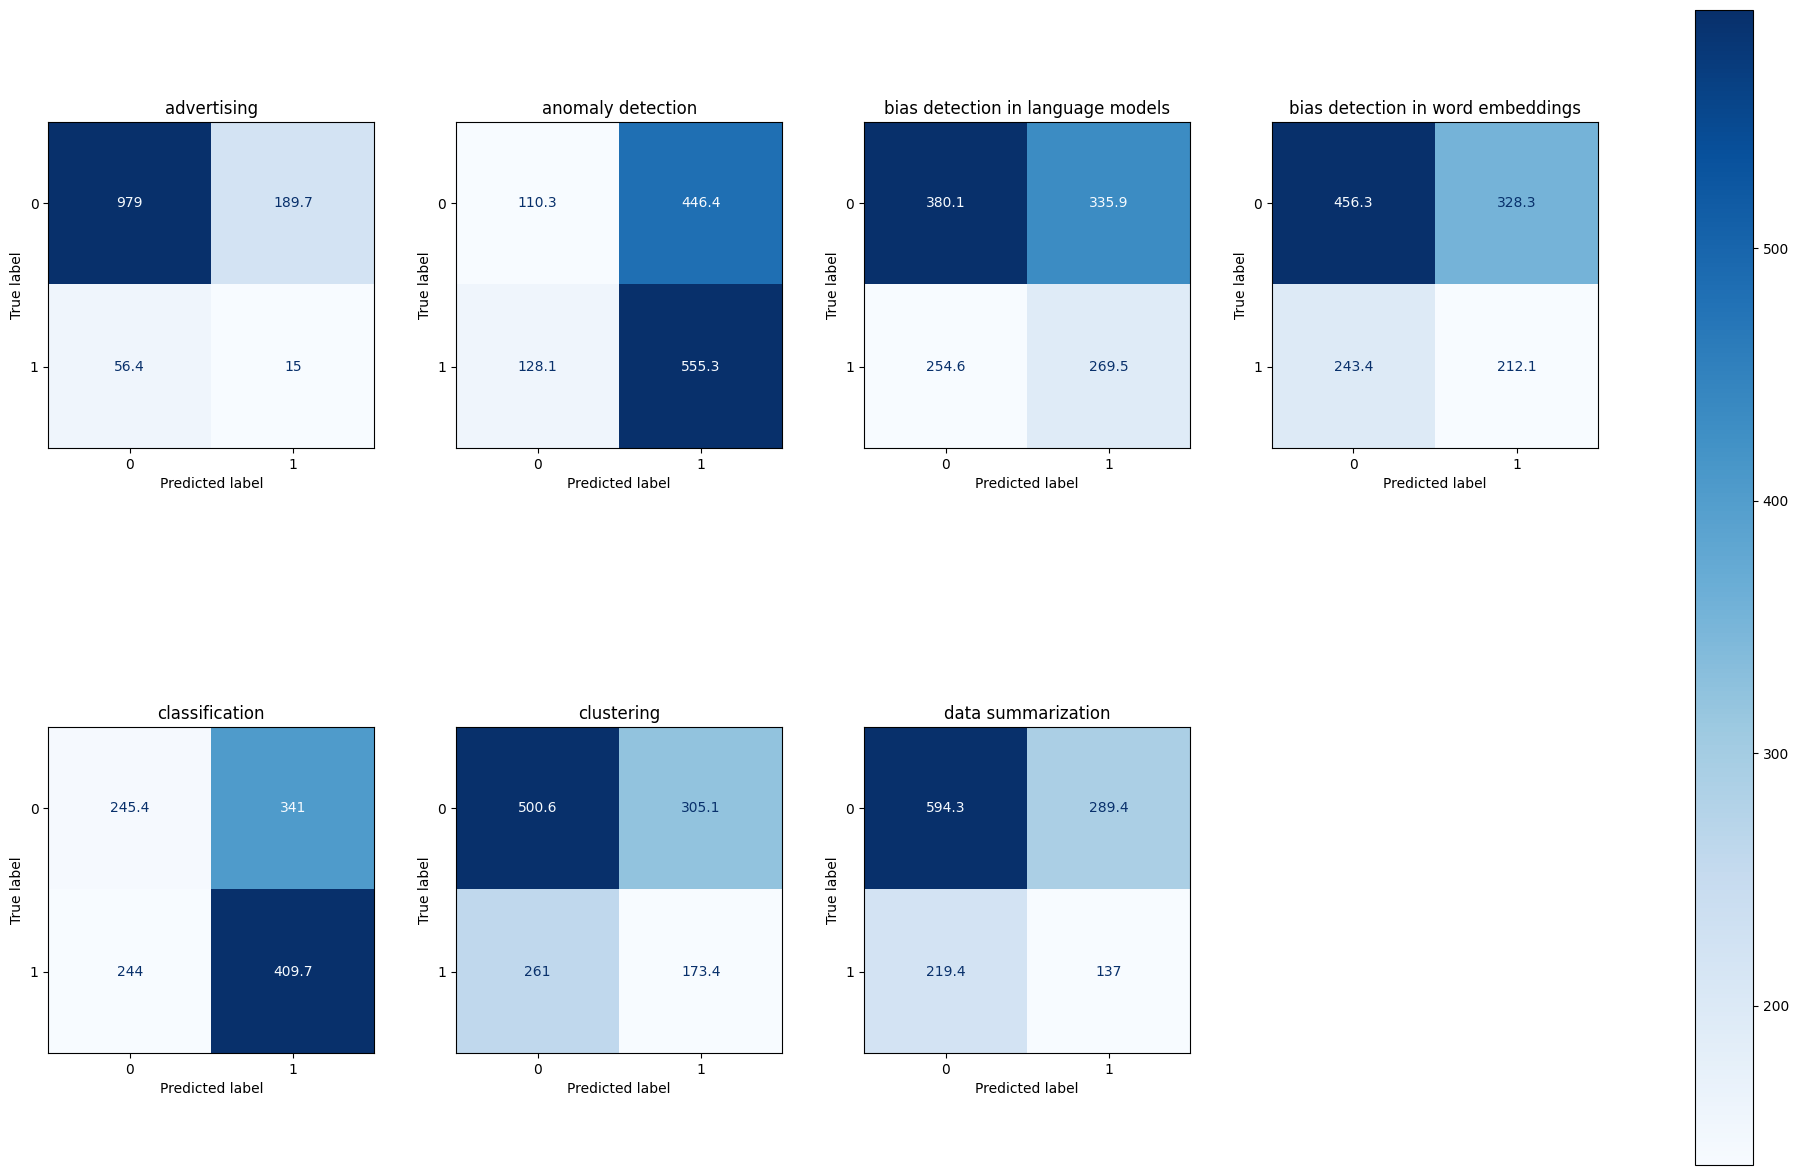

In [27]:
model = GaussianNB()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, LabelPowerset, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### k-NearestNeighbors

Training on fold 1/10...
Training on fold 2/10...
Training on fold 3/10...
Training on fold 4/10...
Training on fold 5/10...
Training on fold 6/10...
Training on fold 7/10...
Training on fold 8/10...
Training on fold 9/10...
Training on fold 10/10...
Precision: 0.6382540175095984
Recall Score: 0.48298382726242534
F1 Score: 0.5497355750399426
Hamming Loss: 0.19812967010115512


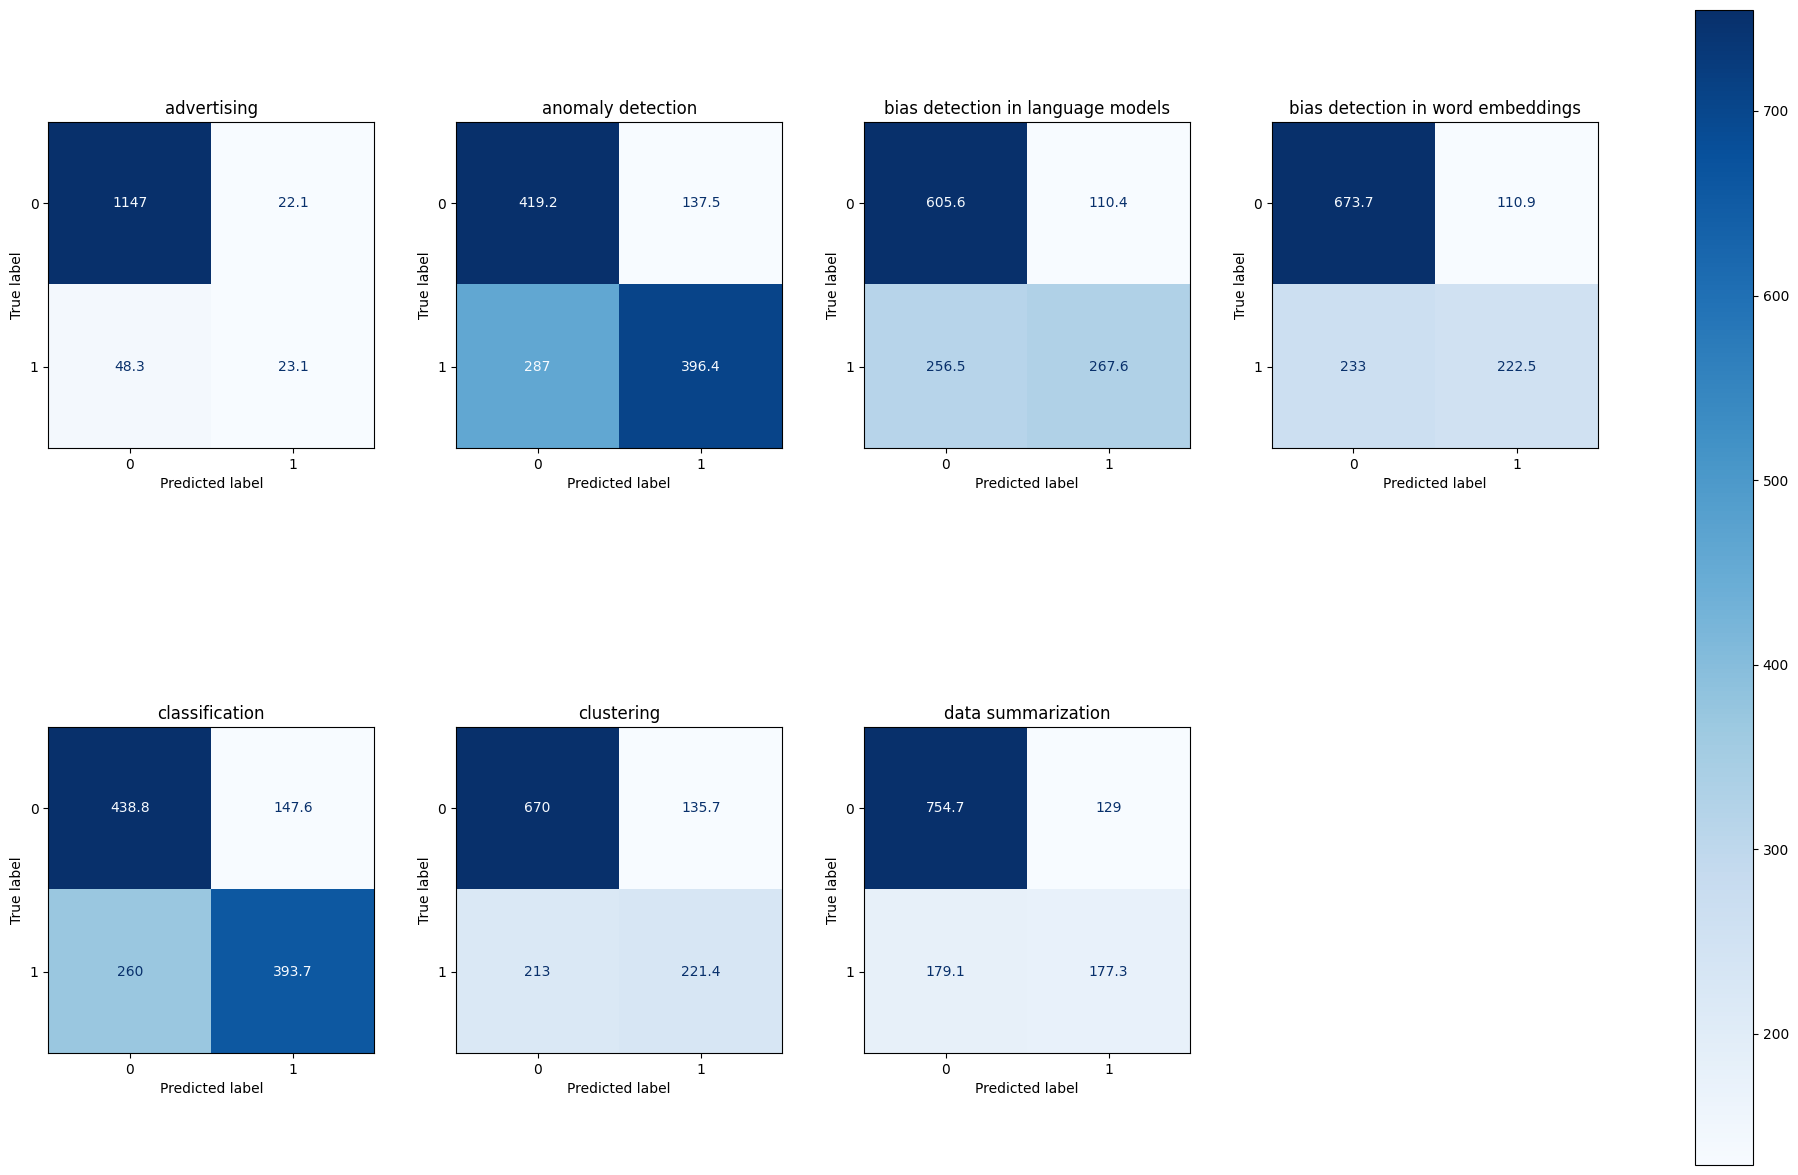

In [28]:
model = KNeighborsClassifier()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, LabelPowerset, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### Decision Tree

Training on fold 1/10...
Training on fold 2/10...
Training on fold 3/10...
Training on fold 4/10...
Training on fold 5/10...
Training on fold 6/10...
Training on fold 7/10...
Training on fold 8/10...
Training on fold 9/10...
Training on fold 10/10...
Precision: 0.8644914091164573
Recall Score: 0.8639655493813265
F1 Score: 0.864181135095927
Hamming Loss: 0.06801554067699347


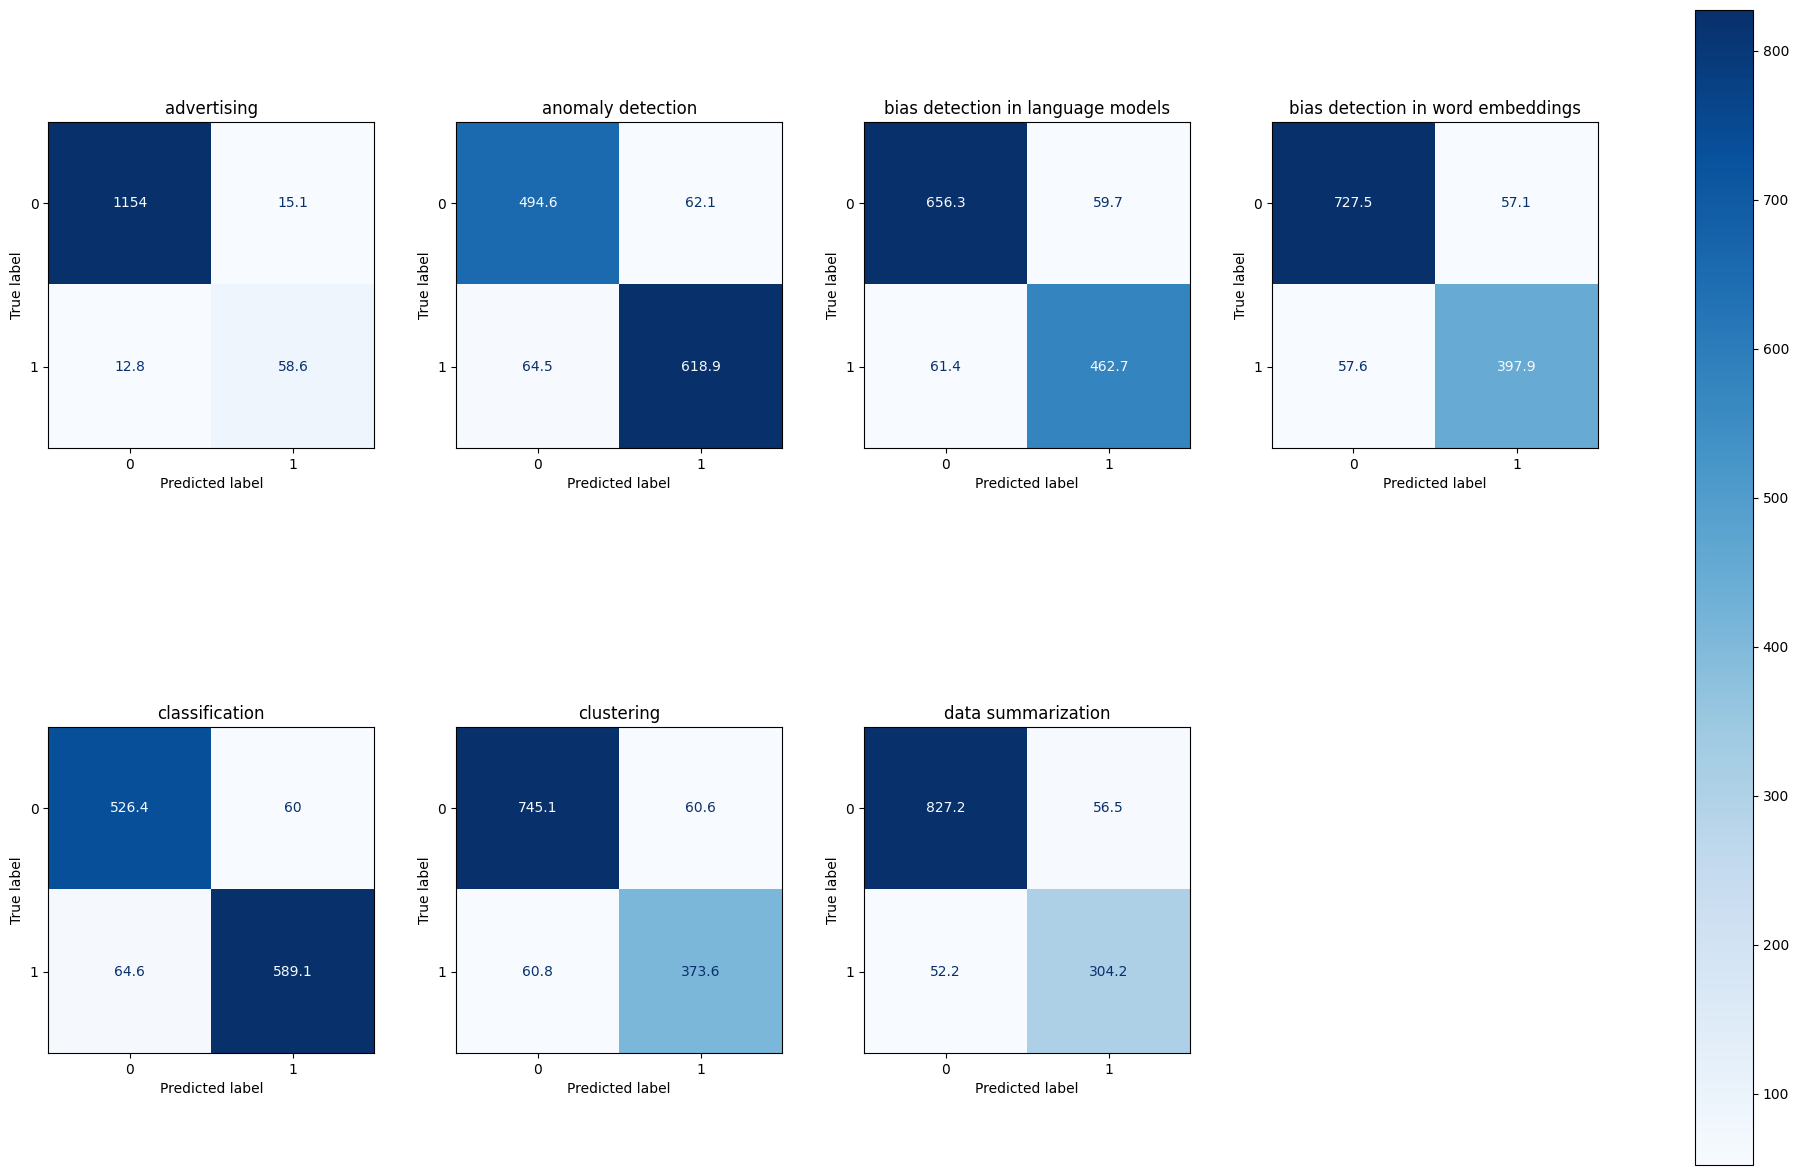

In [29]:
model = DecisionTreeClassifier()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, LabelPowerset, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

#### Support Vector Machine

Training on fold 1/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training on fold 2/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training on fold 3/10...


...

Training on fold 9/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Training on fold 10/10...


c:\Users\pc\Desktop\Fairness Classification\myenv\lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Precision: 0.3861338028907138
Recall Score: 0.4275325972309162
F1 Score: 0.3975187336520796
Hamming Loss: 0.3179365851000654


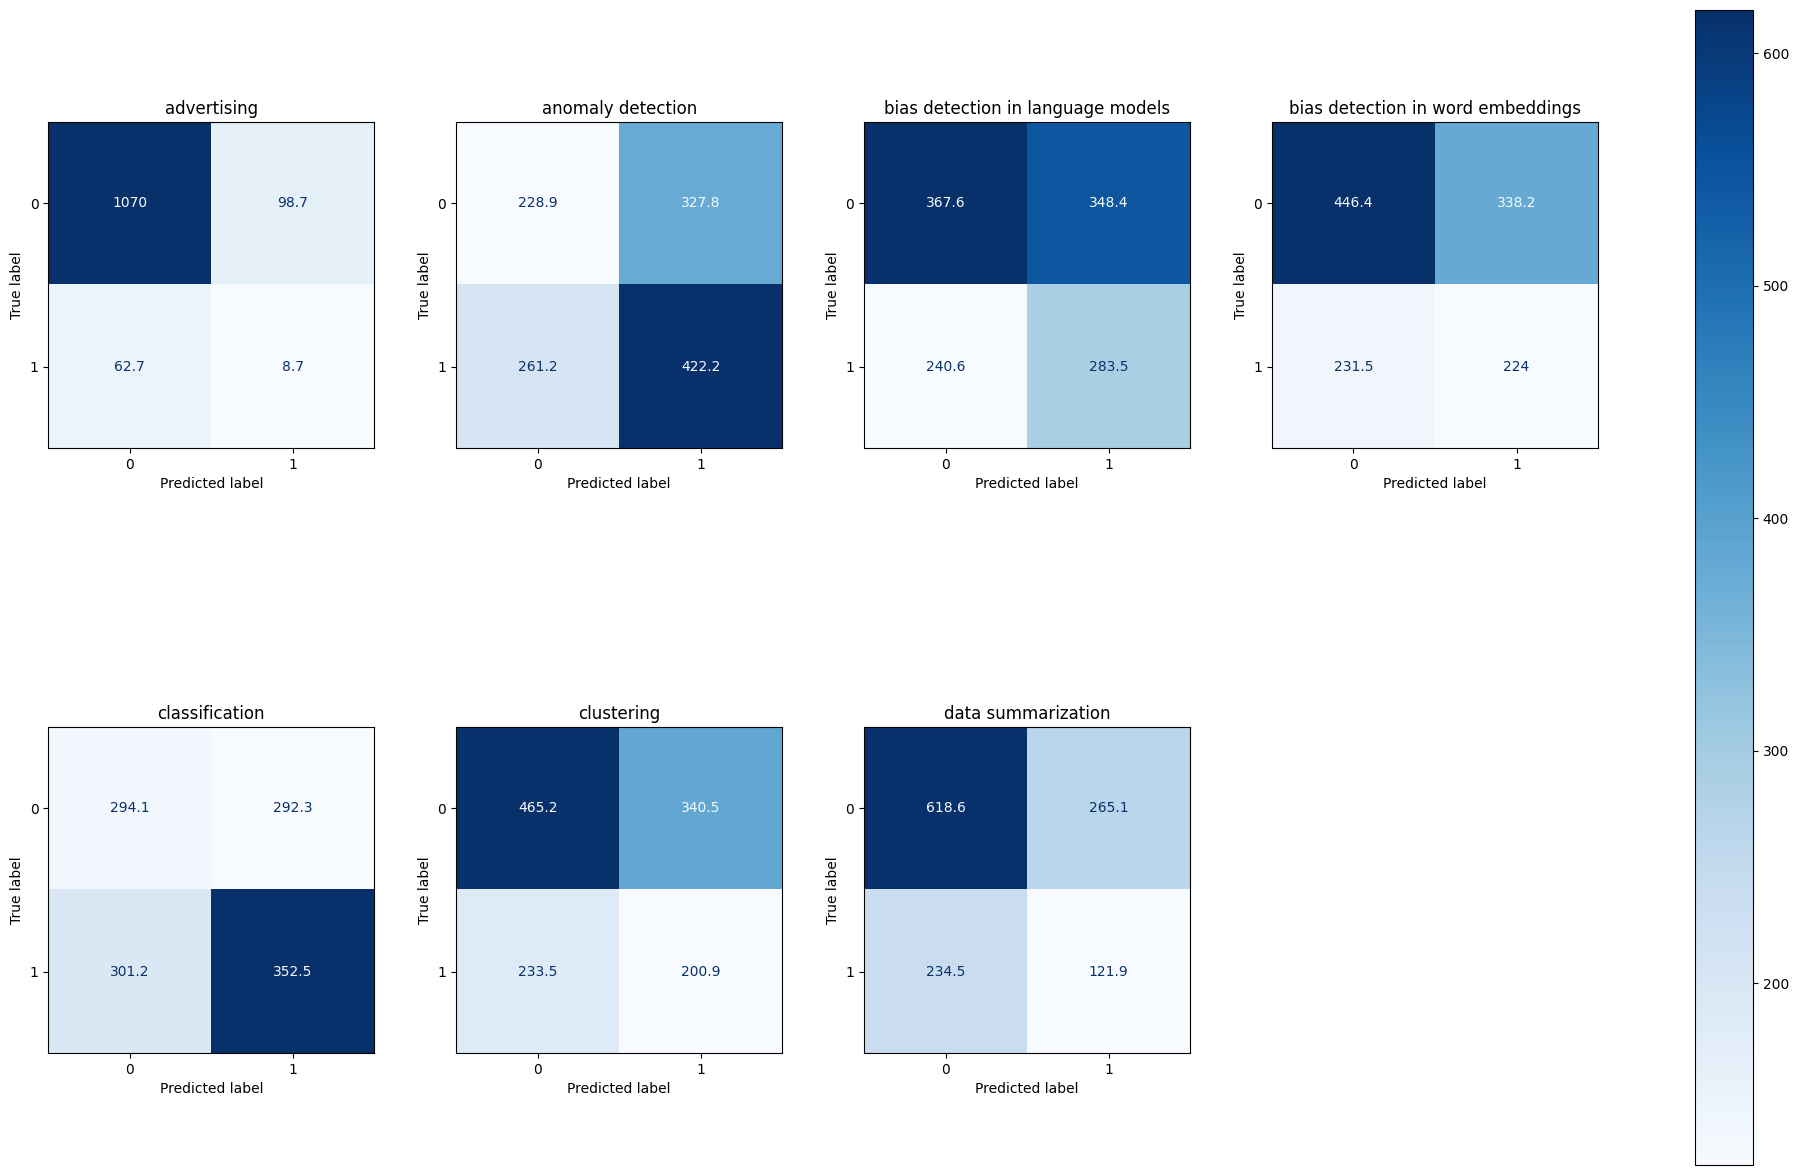

In [30]:
model = LinearSVC()
prec_score, rec_score, f_score, ham_loss, conf_matrix = build_model(model, LabelPowerset, X, y)

print('='*50)
print("Precision: " + str(np.mean(prec_score)))
print("Recall Score: " + str(np.mean(rec_score)))
print("F1 Score: " + str(np.mean(f_score)))
print("Hamming Loss: " + str(np.mean(ham_loss)))
plot_confusion_matrix(np.mean(conf_matrix, axis=0))

## Risultati classifcatore multi-label

In [31]:
with pd.ExcelWriter('./resultsMultilabel/resultsMULTILABELS.xlsx', mode='a',if_sheet_exists='replace') as writer:
    results.to_excel(writer, sheet_name='MultiLabelClf BERT')

results.head()

,BinaryRelevance LogisticRegression,BinaryRelevance RandomForestClassifier,BinaryRelevance GaussianNB,BinaryRelevance LinearSVC,BinaryRelevance KNeighborsClassifier,BinaryRelevance DecisionTreeClassifier,ClassifierChain LogisticRegression,ClassifierChain RandomForestClassifier,ClassifierChain GaussianNB,ClassifierChain LinearSVC,ClassifierChain KNeighborsClassifier,ClassifierChain DecisionTreeClassifier,LabelPowerset LogisticRegression,LabelPowerset RandomForestClassifier,LabelPowerset GaussianNB,LabelPowerset LinearSVC,LabelPowerset KNeighborsClassifier,LabelPowerset DecisionTreeClassifier
F1-mean,0.315313,0.7489,0.18512,0.385059,0.577692,0.77577,0.316181,0.767454,0.188161,0.371164,0.576574,0.701118,0.452526,0.839106,0.395903,0.397519,0.549736,0.864181
Precision-mean,0.559441,0.918665,0.143886,0.372981,0.679934,0.770945,0.560527,0.808135,0.144881,0.364898,0.681757,0.701241,0.479286,0.900409,0.345097,0.386134,0.638254,0.864491
Recall-mean,0.219557,0.632133,0.259698,0.401429,0.502296,0.78074,0.220273,0.730921,0.268765,0.383288,0.499646,0.70127,0.428744,0.785686,0.464715,0.427533,0.482984,0.863966
Hammer-Loss-mean,0.238793,0.10609,0.572512,0.320216,0.183906,0.113018,0.238572,0.110897,0.579941,0.322892,0.183699,0.149719,0.259756,0.075446,0.354652,0.317937,0.19813,0.068016
F1-fold1,0.320407,0.768433,0.192385,0.366687,0.577083,0.777301,0.311813,0.759265,0.185067,0.354005,0.567901,0.703428,0.465336,0.835934,0.419514,0.336507,0.560675,0.866068


In [32]:
with pd.ExcelWriter('./resultsMultilabel/multilabel-clf-bert.xlsx', engine='openpyxl', mode='w') as writer:
  df_pred1.to_excel(writer, sheet_name='Fold 1')
with pd.ExcelWriter('./resultsMultilabel/multilabel-clf-bert.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
  df_pred2.to_excel(writer, sheet_name='Fold 2')
with pd.ExcelWriter('./resultsMultilabel/multilabel-clf-bert.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
  df_pred3.to_excel(writer, sheet_name='Fold 3')
with pd.ExcelWriter('./resultsMultilabel/multilabel-clf-bert.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
  df_pred4.to_excel(writer, sheet_name='Fold 4')
with pd.ExcelWriter('./resultsMultilabel/multilabel-clf-bert.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
  df_pred5.to_excel(writer, sheet_name='Fold 5')
with pd.ExcelWriter('./resultsMultilabel/multilabel-clf-bert.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
  df_pred6.to_excel(writer, sheet_name='Fold 6')
with pd.ExcelWriter('./resultsMultilabel/multilabel-clf-bert.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
  df_pred6.to_excel(writer, sheet_name='Fold 6')
with pd.ExcelWriter('./resultsMultilabel/multilabel-clf-bert.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
  df_pred7.to_excel(writer, sheet_name='Fold 7')
with pd.ExcelWriter('./resultsMultilabel/multilabel-clf-bert.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
  df_pred8.to_excel(writer, sheet_name='Fold 8')
with pd.ExcelWriter('./resultsMultilabel/multilabel-clf-bert.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
  df_pred9.to_excel(writer, sheet_name='Fold 9')
with pd.ExcelWriter('./resultsMultilabel/multilabel-clf-bert.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
  df_pred10.to_excel(writer, sheet_name='Fold 10')